## Content


- **Business Case Introduction - Aspect based Sentiment Analysis**
  - what is 'aspect' in ML?

- **Classification using LSTM**

- **Classification using LSTM + ATTENTION**
  - What are Attention Mechanisms
  - Why Attention Mechanisms?
  - Why Attention + LSTM


- **Mathematical Representation of attentions**
  - General Attention mechanisms Formula


- **How to compute attention?**

    - ASSESSMENT

- **Different types of alignment function/ Energy function**
  1. Similarity based Alignment functions
  2. General alignment function
  3. Additive alignment function
  4. Location-based alignment

- **Different types of Attention Mechanisms**
  1.   Attention mechanisms based on Number of Sequences
    1. Distinctive Attention Mechanisms
    2. Self Attention AM

  2.   Attention mechanisms based on Number of Position
    1. Soft Attention Mechanisms
    2. Hard Attention Mechanisms

  1.   Attention mechanisms based on Number of Abstraction
    1. Single-Level Attention Mechanisms
    2. Multi-Level Attention Mechanisms

  2.   Attention mechanisms based on Number of Representation
    1. Single-Headed Attention Mechanisms
    2. Multi-Headed Attention Mechanisms

- **Lets Compute one of the popular Multi-headed attention in NLP.**

- **Code**
    
- **Attention Plot Analysis**


<a href="https://colab.research.google.com/github/scaleracademy/dsml-course/blob/main/NLP_Lecs/L_91_Intro_to_Attention_mechanisms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install tensorflow_addons
%pip install lit-nlp
%pip install rouge-score
%pip install shap

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 591.0/591.0 kB 10.1 MB/s eta 0:00:00
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 45.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 9.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 7.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.2/88.2 kB 6.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 61.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for ml-collections: filename=ml_collections-0.1.1-py3-none-any.whl size=94524 sha256=e70fa0da135c24420635411464d050a96f9c75b604dd98dc4beb8da1b49aab43
  Stored in directory: /root/.c

In [ ]:
import pandas as pd
import numpy as np
import string
import re
import random
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from gensim.models import word2vec, FastText
import gensim.downloader
from sklearn.decomposition import PCA
import tensorflow_addons as tfa

/usr/local/lib/python3.9/dist-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(


## **Problem Statement**

## **So, What kind of problem is it?**
- so, first thing it is clear that, it is a  sentiment analysis task.
-  but sentiment is based on entity present in the review itself.
- so we have two input :
  - First, is `review text`,
  - and Second, is an `entity text` on which we want sentiment analysis.

- This type of task is categorized as `Aspect based Sentiment Analysis` in ML.



### **what is 'aspect' in ML?**
- the way in which a problem, idea, etc., may be considered  

- like your goal is to do classification based on some aspect. see below examples.

```
INPUT = {'text': 'food is delicious but price is high',
             'aspect':'food',
              
   }

   OUTPUT = {'aspect_Sentiment' : 'Positive'
                }

```
     



- You are a data scientist in travel agency company.

- Your company is trying to figure out the sentiment of people about the  Hotel and Restaurant listed on their website on the basis of entity present in the review itself.
-  so that they could rank the hotel and restaurant accordingly on their landing page.

- And they wanted to train you a ML model to solve the problem.

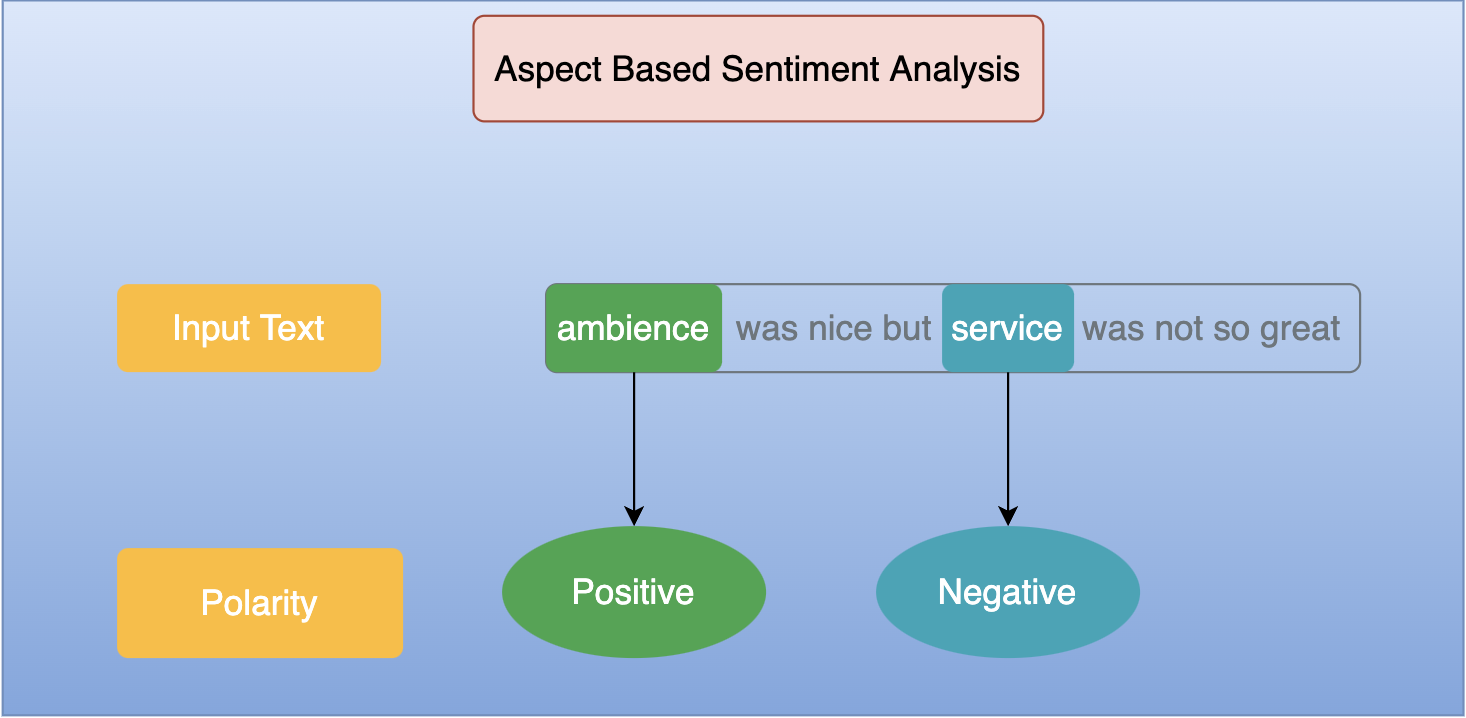

# **How we approach this problem?**

1. `Classification using LSTM.`
2. `Attention + LSTM Based Classification.`



# **1. Classification Using LSTM.**

- Take embedding of both Review Text and Aspect Text.
- Concate the embedding vectors into single sequence.
- Pass the output of concat layer to LSTM.
- LSTM followed by a couple of dense layer before final prediction.

## **How is the accuracy of Model?**
- After training, LSTM model achieves accuracy of 72%

## **How to improve the performance?**

- Using attention mechanisms.
- It acts like temprory memory for our model.

# **2. Classification Using LSTM + ATTENTION**



## **What are Attention Mechanisms**





>  " the action of taking special care of something."






- The intuition behind attention can be best explained using human biological systems.

- For example,
our visual processing system tends to focus selectively on some parts of the image, while ignoring
other irrelevant information in a manner that can assist in perception.   

- Similarly, in
several problems involving language, speech or vision, some parts of the input are more important
than others.
```
Attention Mechanisms (AM) incorporates this notion of relevance by allowing the model to dynamically pay
attention to only certain parts of the input that help in
performing the task at hand effectively.
```
- An example of sentiment classification of Yelp reviews using AM is shown in
below figure.
- In this example, the AM learns that out of five sentences, the first and third sentences
are more relevant. Furthermore, the words delicious and amazing within those sentences are more
meaningful to determine the sentiment of the review.

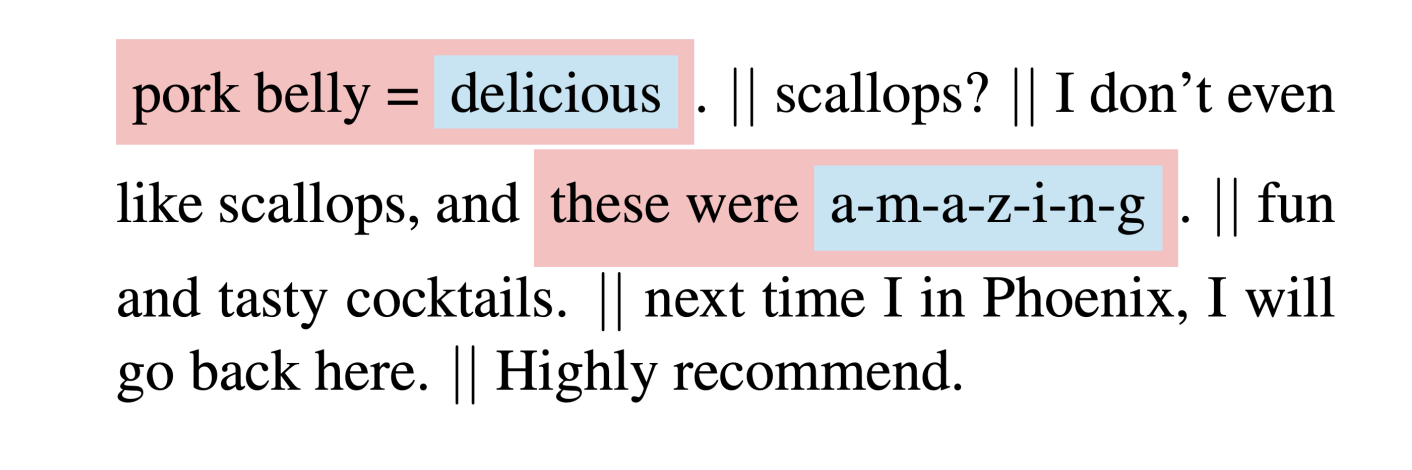

## **Why Attention Mechanisms?**


- These models are now the state-of-the-art for multiple tasks in

Domain | Task
--------|-----------
NLP | Machine Translation,Summarization, Sentiment Analysis, and Part-of-Speech tagging
Computer Vision | Image Classification, Object Detection, Image Generation
Cross-Modal Tasks |  Multimedia Description, Visual Question Answering  and Recommender Systems

- Improves `performance` on the main task.

- Extensively used for improving `interpretability of
neural networks`, which are otherwise considered as black-box models.

- Helps in debugging the `fairness`, `accountability`, and `transparency of Machine
Learning models` in applications that influence human lives.

## **Why Attention + LSTM**

- Attention mechanisms help overcome some
challenges with Recurrent Neural Networks(RNNs) such as performance degradation with increase
in length of the input and the computational inefficiencies resulting from sequential processing of
input.

# **What is the Mathematical Representation of attentions?**

The core of the attention mechanism maps a
sequence $K$ of $n$ vectors,\
 $k_i$  the $Keys$, to a aligment distribution $a$ of $n$ weights $a_i$ .

***Attention mechanisms Consist of following Componets:***
1. `Key(K)`
2. `Query(Q)`
3. `Value(V)`
4. `Energy Function(a)`
5. `Alignment distribution(g)`
6. `Final Representation(C)`

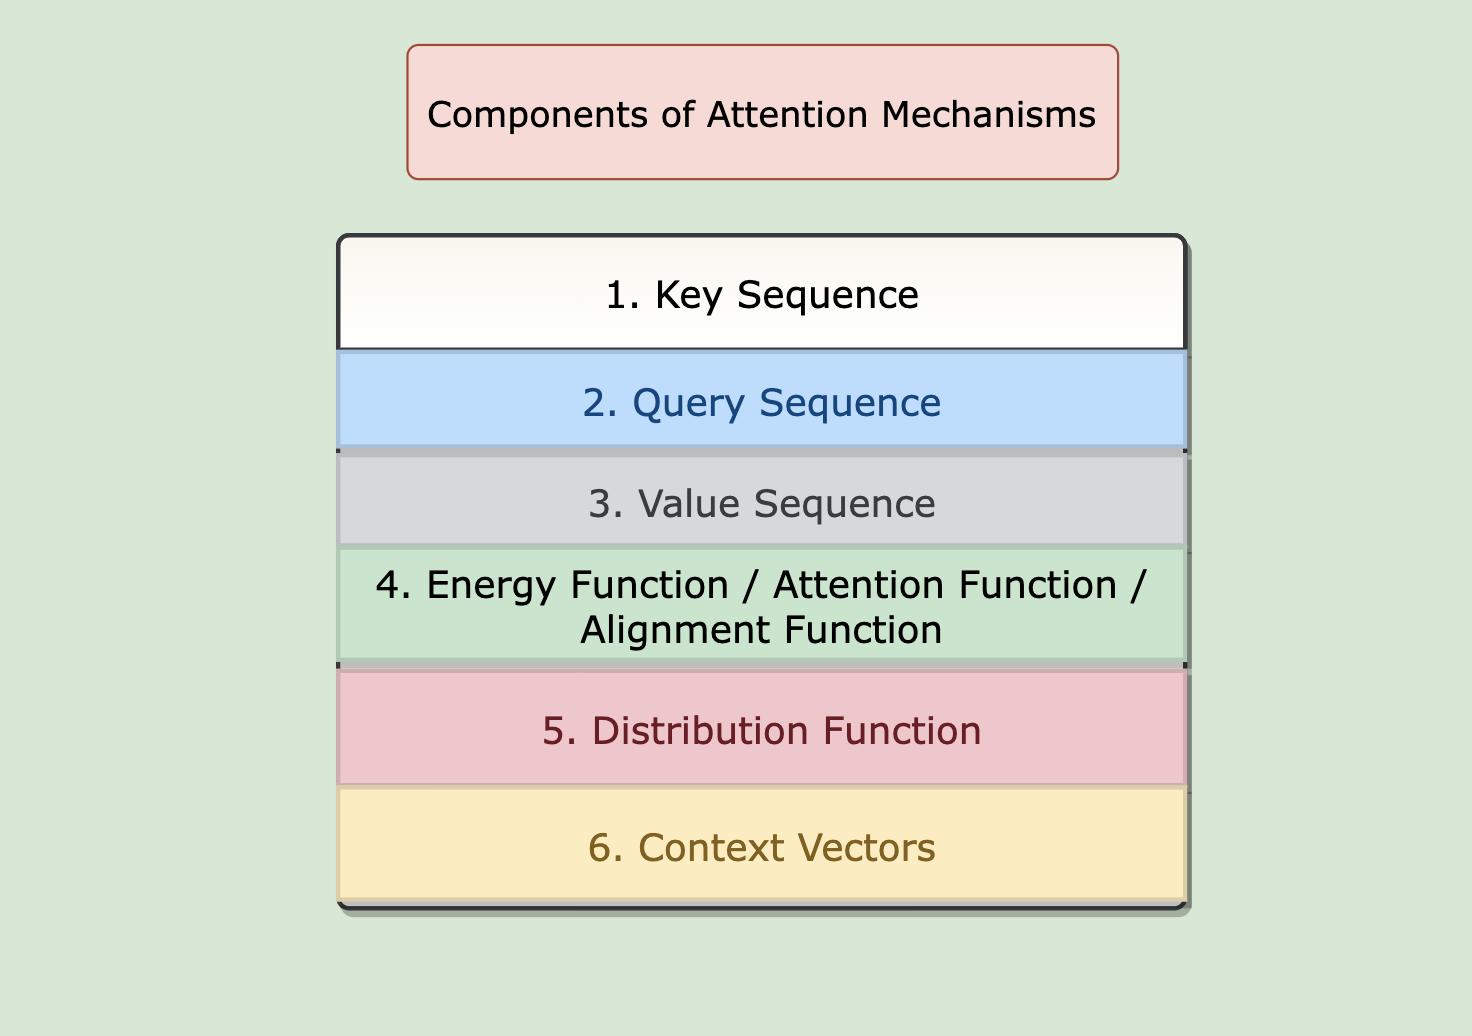

## **General Attention mechanisms Formula**

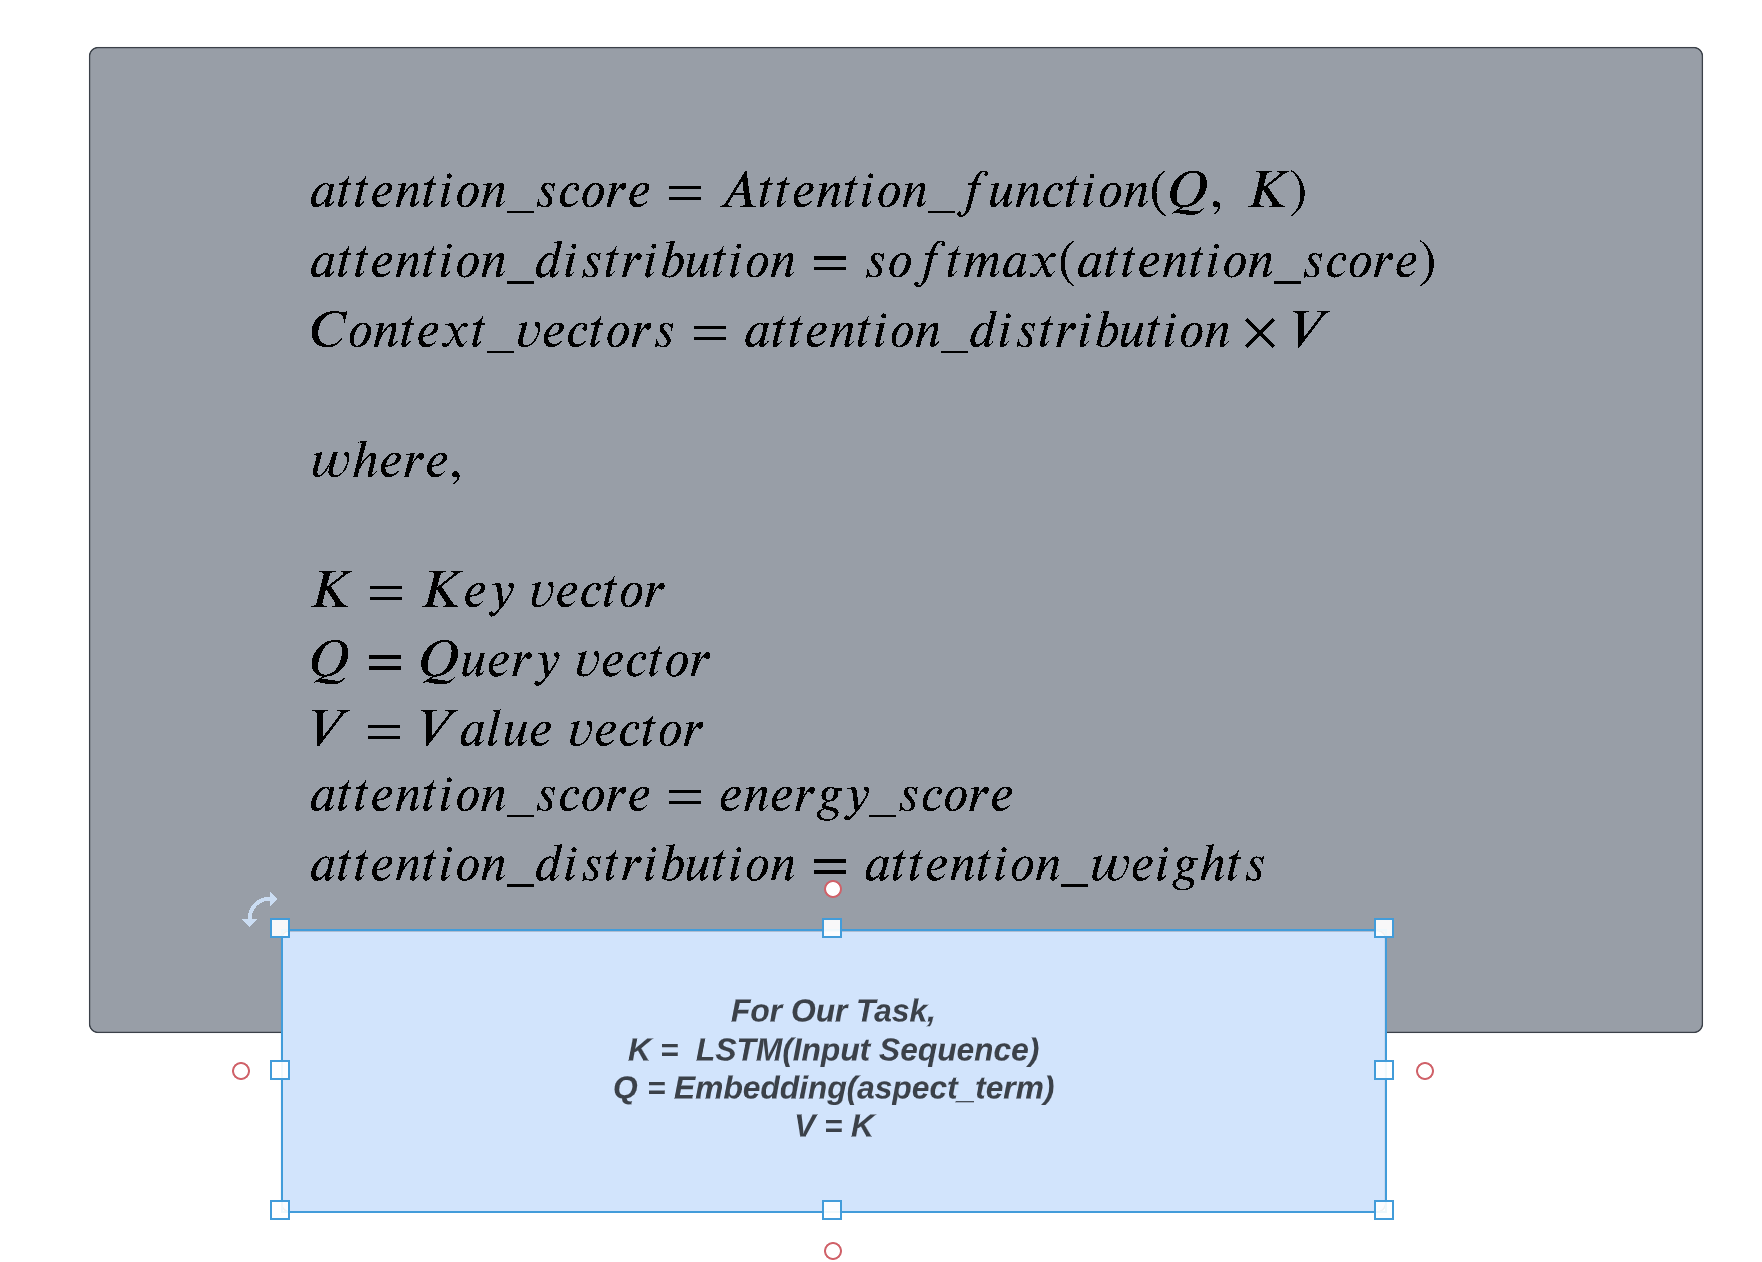



### **1. Key**
-  K encodes the data features whereupon
attention is computed.
-  $K$ may be word or
character embeddings of a document, or the internal states
of a recurrent architecture.

### **2. Query**
- Another input element called $Query$
is used as a reference when computing the attention distribution.
- The attention mechanism will give emphasis
to the input elements relevant to the task according to $Q$.
- $Q$ is represented by embeddings of actual textual queries, contextual information,etc.

### **3. Attention Function/ Energy function**

- also called as alignment function.
- From the $Keys$ and $Query$, a vector $E$ of $n$ energy scores/attention score $e_i$
is computed through a alignment function $\alpha$



   > $E = \alpha (Q, K)$

   > Function $\alpha$  called as  Attention function.



  

### **4. Alignment Distribution**
- Attention scores are then transformed into attention weights using distribution function $g$


  >  $ W = g(E) $


- Such weights are the outcome of the core attention mechanism.
- The commonest distribution function is the softmax



  > $ W = Softmax(E) $

- Weights represent the relevance of
each element to the given task, with respect to $Q$  and $ K$.

### **5. Value**

- The computation of these weights may already be sufficient
for some tasks, such as the classification task.
-  Many tasks require the computation
of new representation of the keys. In such cases, it is common
to have another input element; a sequence $V$ of $n$ vectors
$v_i$ , the values, representing the data whereupon the attention
computed from $K$ and $Q$ is to be applied.

### **6. Final Representation.**


  >  $ Z = W * V $

- Each element of $V$
corresponds to one and only one element of $K$, and the two can
be seen as different representations of the same data.
- Indeed,
many architectures, do not distinguish
between $K$ and $V$.
- $V$ and $W$ are thus combined to obtain a new set $Z$ of
weighted representations of $V$,

- which are then
merged together so as to produce a compact representation

  > $z_i =  w_i * v_i, $

  > $C = \sum_{i=1}^{d_k} (z_i), $



# **How to compute attention?**




Ex - we have source sentence of 6 words and a target word , and we have to calculate attention score and context vector for target word.

-  Assume source sentence `food is delicious but price is high`
- target words `tasty`
- word `3` is similar in context to `target words`.






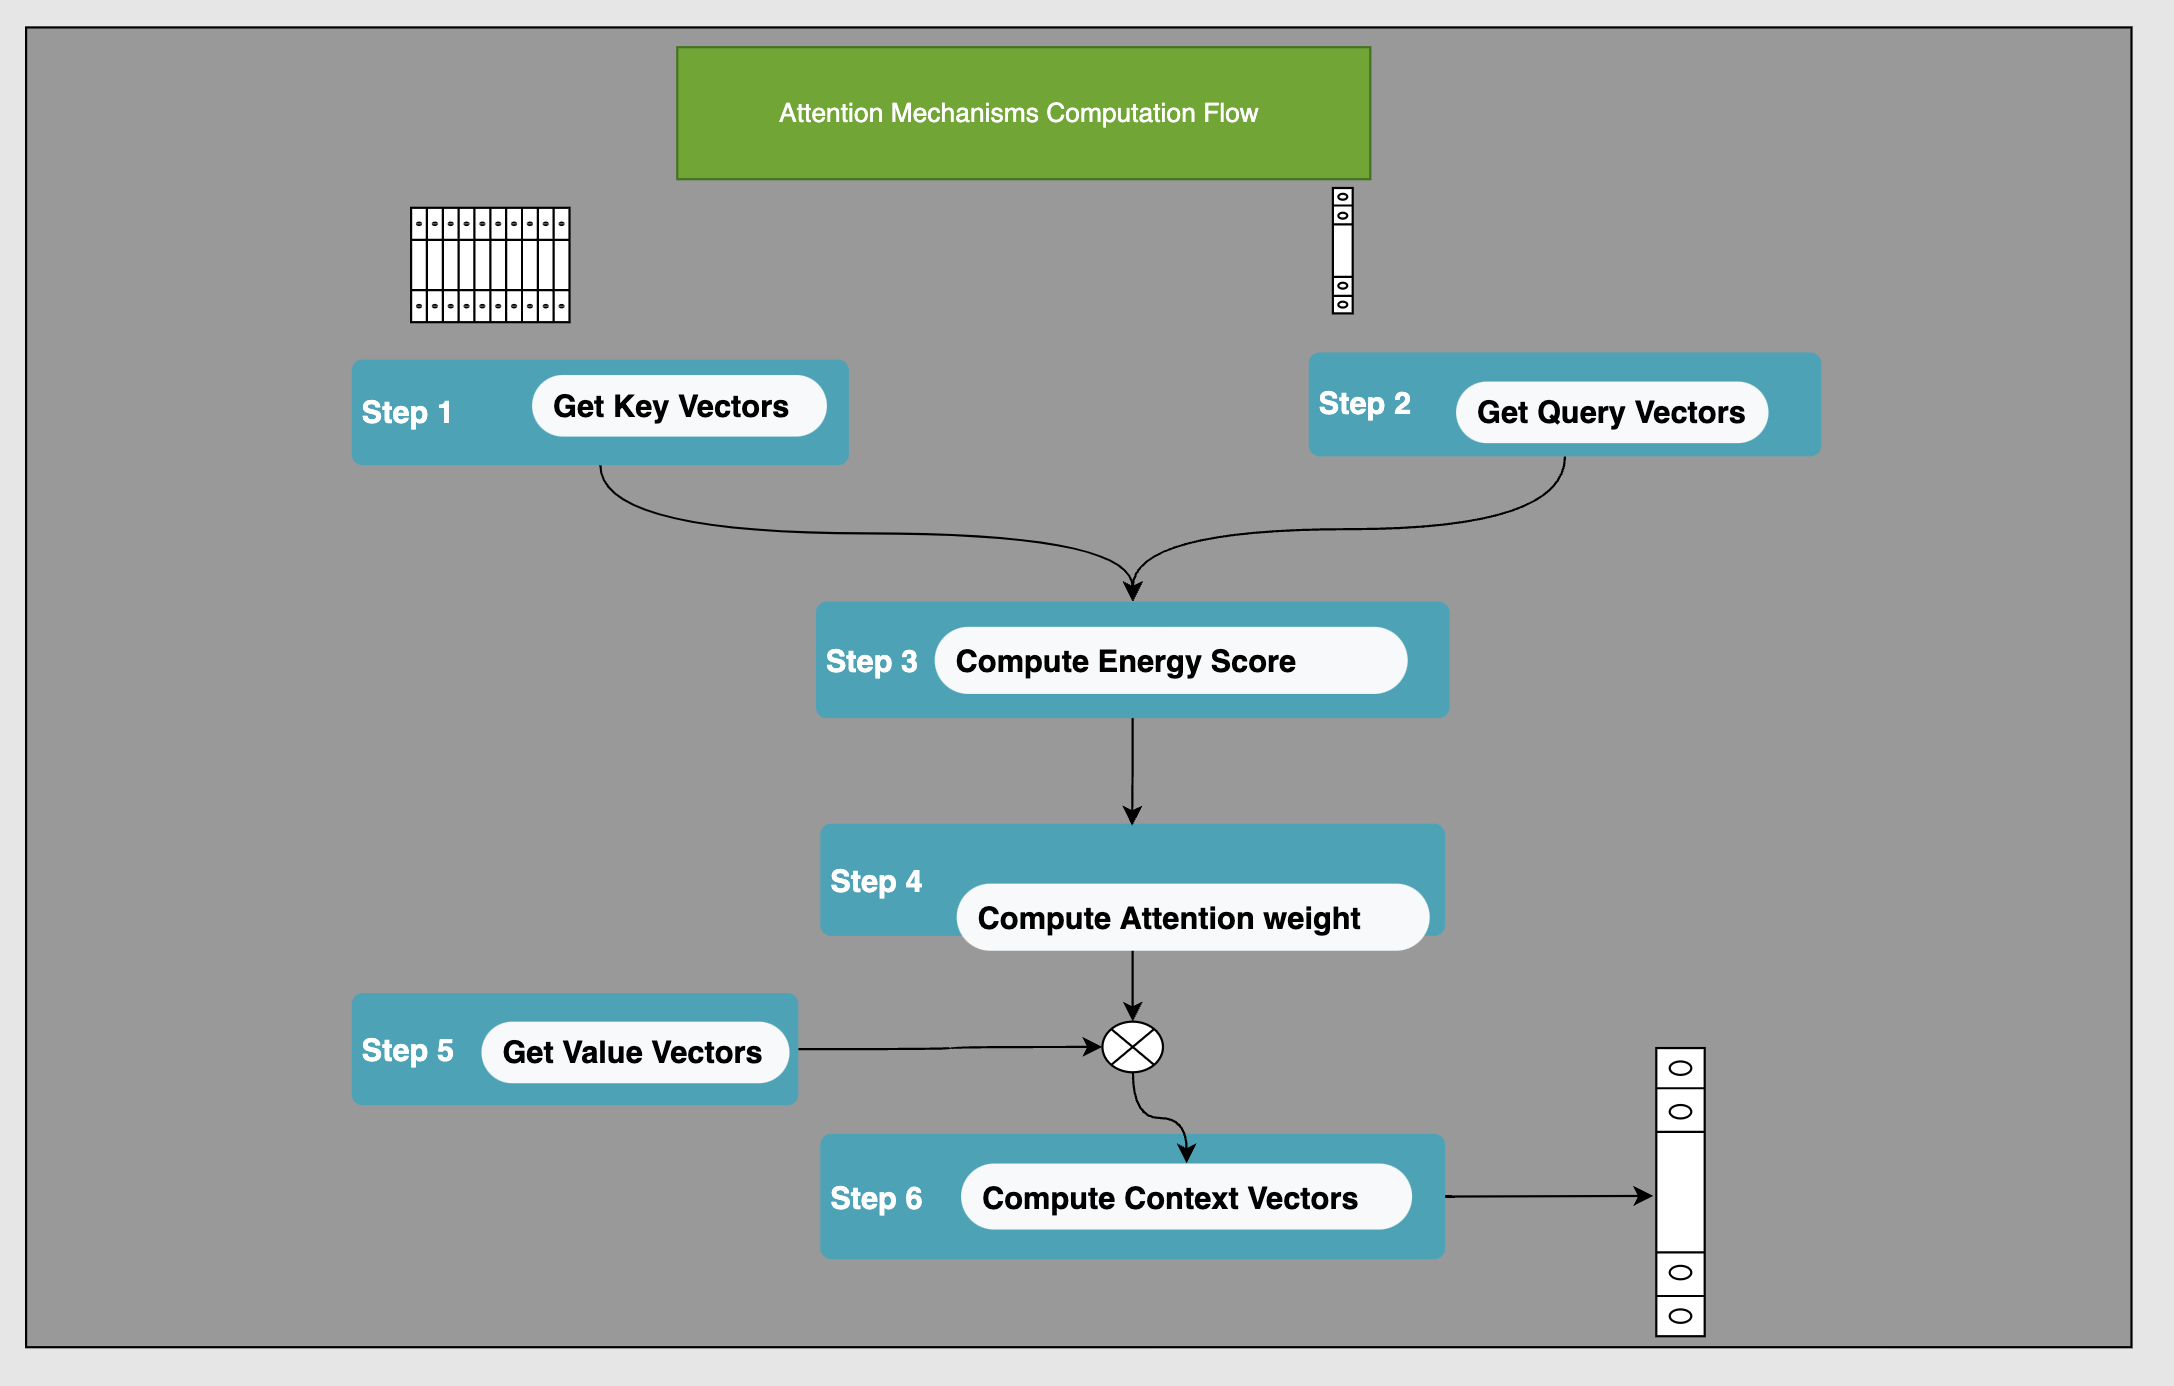

In [ ]:
#load glove word embedding vectors
glove_vectors = gensim.downloader.load('glove-twitter-25')

## **1. Get KEY**

> $Source Sentence $ = "food is delicious but price is high" \
$Tokenized$ = [food, is, delicious, but, price, is, high] \
$Key$ = $representation(Tokenized)$

Here, $representation$ is nothing but a word embedding model or output from recurrent model.


In [ ]:
#Input
sentences = ['food', 'is', 'delicious', 'but', 'price', 'is', 'high']

#Dimensionality reduction for easy visualization.
pca = PCA(n_components=5)

# Key sequence
KEY = [glove_vectors[i].tolist() for i in sentences]
KEY = pca.fit_transform(KEY)

# PLot
plt.figure(figsize=(10.5, 7.5))
key_df = pd.DataFrame(np.transpose(np.matrix(KEY)), columns = sentences)
ax = sns.heatmap(key_df, annot=True, cmap=sns.light_palette("purple", as_cmap=True), linewidths=1, ).set_title('KEY Vector')

## **2. Get Query**


> $target$ = [tasty, cost]\
$QUERY$ = $representation(target)$

Here, $representation$ is nothing but a word embedding model.

In [ ]:
#Query text
target = [ 'cost']

#Query embedding and dimensionality reduction
QUERY = [glove_vectors[i].tolist() for i in target]
QUERY = pca.transform(QUERY)


#Plot
plt.figure(figsize=(10.5, 7.5))
query_df = pd.DataFrame(np.transpose(QUERY), columns = target)
ax = sns.heatmap(query_df, annot=True, cmap=sns.light_palette("grey", as_cmap=True), linewidths=1, ).set_title('QUERY Vector', )

## **3. Compute Energy Function.**

> Here, Energy Function is $Dot Product$.

In [ ]:
def compute_energy_function(vect, mat):
  # calculate energy/attention fuction
  return np.matmul( mat, np.transpose(vect),)

ENERGY_SCORE = compute_energy_function(QUERY, KEY)
ENERGY_SCORE

## **4. Compute Attention weights**

In [ ]:
def softmax(x):
    # Compute attention weights
    x = np.array(x, dtype=np.float64)
    e_x = np.exp(x)
    return e_x / e_x.sum(axis=0)

ATTN_WEIGHTS = softmax(ENERGY_SCORE)

attn_df = pd.DataFrame(ATTN_WEIGHTS, index = sentences, columns = target)

plt.figure(figsize=(14.5, 7.5))
ax = sns.heatmap(attn_df , annot=True, cmap=sns.light_palette("green", as_cmap=True), linewidths=1).set_title('ATTN_WEIGHTS', )

## **5. VALUE**

Here, VALUE = KEY

In [ ]:
VALUE = np.matrix(KEY)
VALUE[:,1].reshape(1,-1).tolist()
ATTN_WEIGHTS[:, 0][0]

## **6. Context Vectors**

In [ ]:
def apply_attention_scores(attention_weights, annotations):
 # Multiple the annotations by their attention weights
 return  [  annotations[:, i] * attention_weights[i] for i in range(len(attention_weights))]


applied_attention_1 = apply_attention_scores(ATTN_WEIGHTS, np.transpose(VALUE))

plt.figure(figsize=(14.5, 7.5))
ax = sns.heatmap(np.array(applied_attention_1).reshape(7, 5), annot=True, cmap=sns.light_palette("indigo", as_cmap=True), linewidths=1).set_title('QUERY FOOD', )

In [ ]:
def calculate_attention_vector(applied_attention):
 return np.sum(applied_attention, axis=0)

#applied_attention = np.array([[applied_attention_1]])
attention_vector = calculate_attention_vector(applied_attention_1)
plt.figure(figsize=(14.5, 7.5))
ax = sns.heatmap(np.transpose(np.matrix(attention_vector)), annot=True, cmap=sns.light_palette("Green", as_cmap=True), linewidths=1).set_title('Context Vector FOOD', )


# What are the different types of alignment function/ Energy function?


#### **1. Similarity based  Alignment functions**


1.   **Similarity e.g. Cosine Similarity**
2. **Dot Product**
3.   **Scaled Dot Product**



- These Alignment functions based on a notion of comparing query representations with key representations.
- compute either the cosine similarity or the dot product between the key and query representations.

- To account for varying lengths of representation, scaled dot product can be employed that normalizes the dot product by the representation vector length.
- Note that these functions
assume that key and query have the same representation vector space.




$ \Large Attention\_Function \space               $                  | **$ \Large Equation \space        f(Q ,K)                    $**
------------------------|--------------------------------------------------
$\normalsize Similarity/(e.g. Cosine Sim)$ | $\Large Sim(Q,K)$
$ \normalsize Dot Product/Multiplicative$ | $ \Large  Q^TK$
$\normalsize Scaled\_Dot Product$ | $ \Large  \frac{Q^TK }{\sqrt{n}}$

#### **2. General alignment function**



1.   **General alignment**
2.   **Biased general alignment**
3.   **Activated general alignment**




- General alignment extends dot
product to keys and queries with different representations by introducing a learnable transformation
matrix $W$ that maps queries to the vector space of keys.

- Biased general alignment allows to learn
the global importance of some keys irrespective of the query by introducing a bias term.
- Activated
general alignment adds a nonlinear activation layer such as hyperbolic tangent, rectifier linear
unit, or scaled exponential linear unit.



$ \Large Attention\_Function \space               $                  | **$ \Large Equation \space        f(Q ,K)                    $**
------------------------|--------------------------------------------------
$\normalsize General\_ alignment$ | $\Large Q^TWK$
$ \normalsize Biased\_ general\_ alignment$ | $ \Large  K^T(W \cdot Q + b)$
$\normalsize Activated\_ general\_ alignment$ | $ \Large  activation(Q^TWK + b)$


#### **3. Additive alignment function**



1.   **Concat**
2.   **Additive Alignment**
3.   **Deep alignment**


-  combine keys and query to form a joint representation.
-  Additive alignment reduces computational time by decoupling the contributions of the query and
the key
- allows precomputing contributions of all keys to avoid re-computation for each query.
- In contrast to a single neural layer used in additive alignment, deep alignment employs multiple
neural layers.


$ \Large Attention\_Function \space               $                  | **$ \Large Equation \space        f(Q ,K)                    $**
------------------------|--------------------------------------------------
$\normalsize Concat$ | $\Large W \cdot activation(W[K;Q] + b)$
$ \normalsize Additive\_ alignment$ | $ \Large  W \cdot activation(W_1 \cdot K + W_2 \cdot Q + b)$
$\normalsize Deep\_ alignment$ | $ \Large  W \cdot (E^{(L-1)} + B^L) \\ \large E^L = activation(W_lE^{(l-1)} + b^l)$


#### **4. Location-based alignment**
1.  **Convolution Based**
2. **Location Based**

- ignores the keys and only depends on q. The alignment score associated with each key
is thus computed as a function of the key’s position, independently of its content.

- when working with group of items such as 2-D patches for images or 1-D temporal
sequences,
- derived features (such as mean and standard deviation) from the representations of the
individual elements belonging to the group can be used as input to alignment functions


$ \Large Attention\_Function \space               $                  | **$ \Large Equation \space        f(Q ,K)                    $**
------------------------|--------------------------------------------------
$\normalsize Location\_ Basedt$ | $\Large f(Q)$
$ \normalsize Convolution\_ Based$ | $ \Large  f(Q,K) = [e_0; e_1;;;;;e_{d_k}]
\\ \Large e_j = \frac{1}{l}\sum_{i=j-l}^{k}e_{i,j}
\\ \Large activation(W \cdot [k_i; k_{i+1};;;k_{i+l}] + b)$



# What are different type of Attention Mechanisms?

Attention Mechanisms can be broadly categorized into four category:

1. Number of Sequences.
2. Number of Abstraction.
3. Number of Position.
4. Number of Representation.

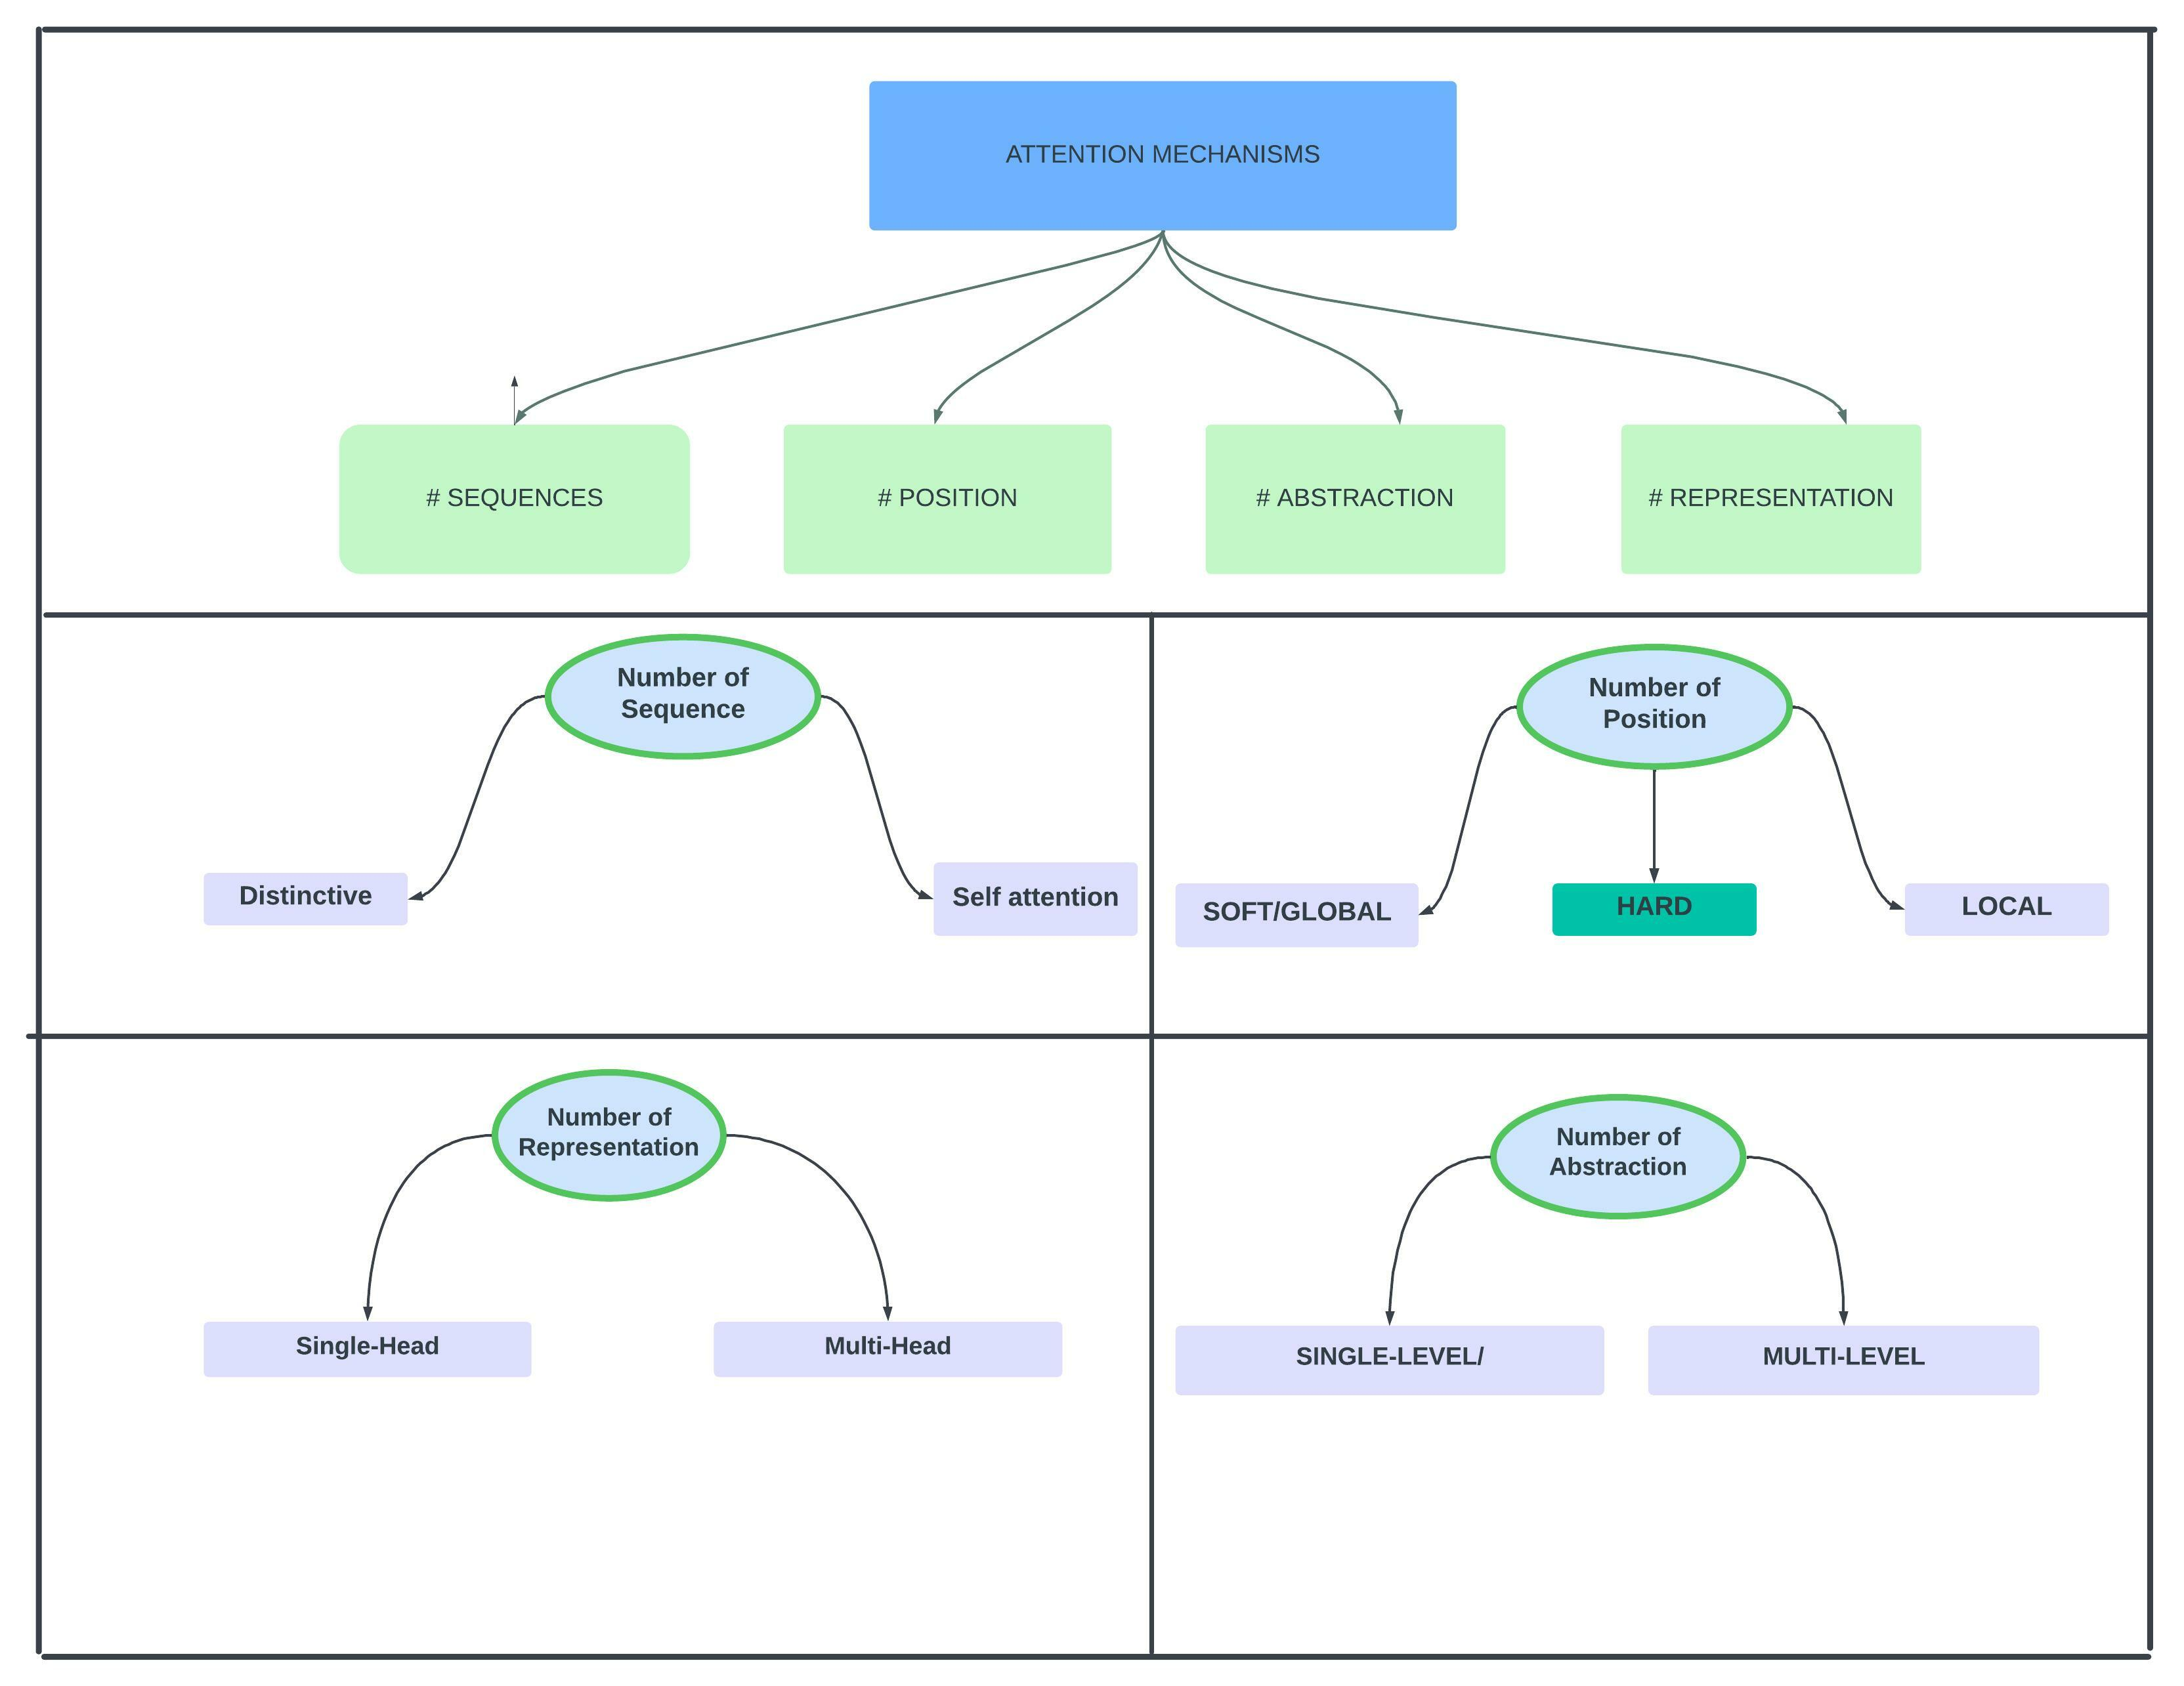

# **What are attention mechanisms based on Number of Sequences?**

### **1. Distinctive Attention Mechanism**s

- In Distinctive Attention Mechanisms, Both key and Query text Sequence is different.
- KEY VECTOR == VALUE VECTOR!= QUERY VECTOR

- ###  **How to Compute Distinctive AM?**
  - Compute KEY, QUERY and VALUE vectors
  - Compute Energy function
  - Compute Attention Score


**Fig Below - Distinctive Attention Mechanisms.**

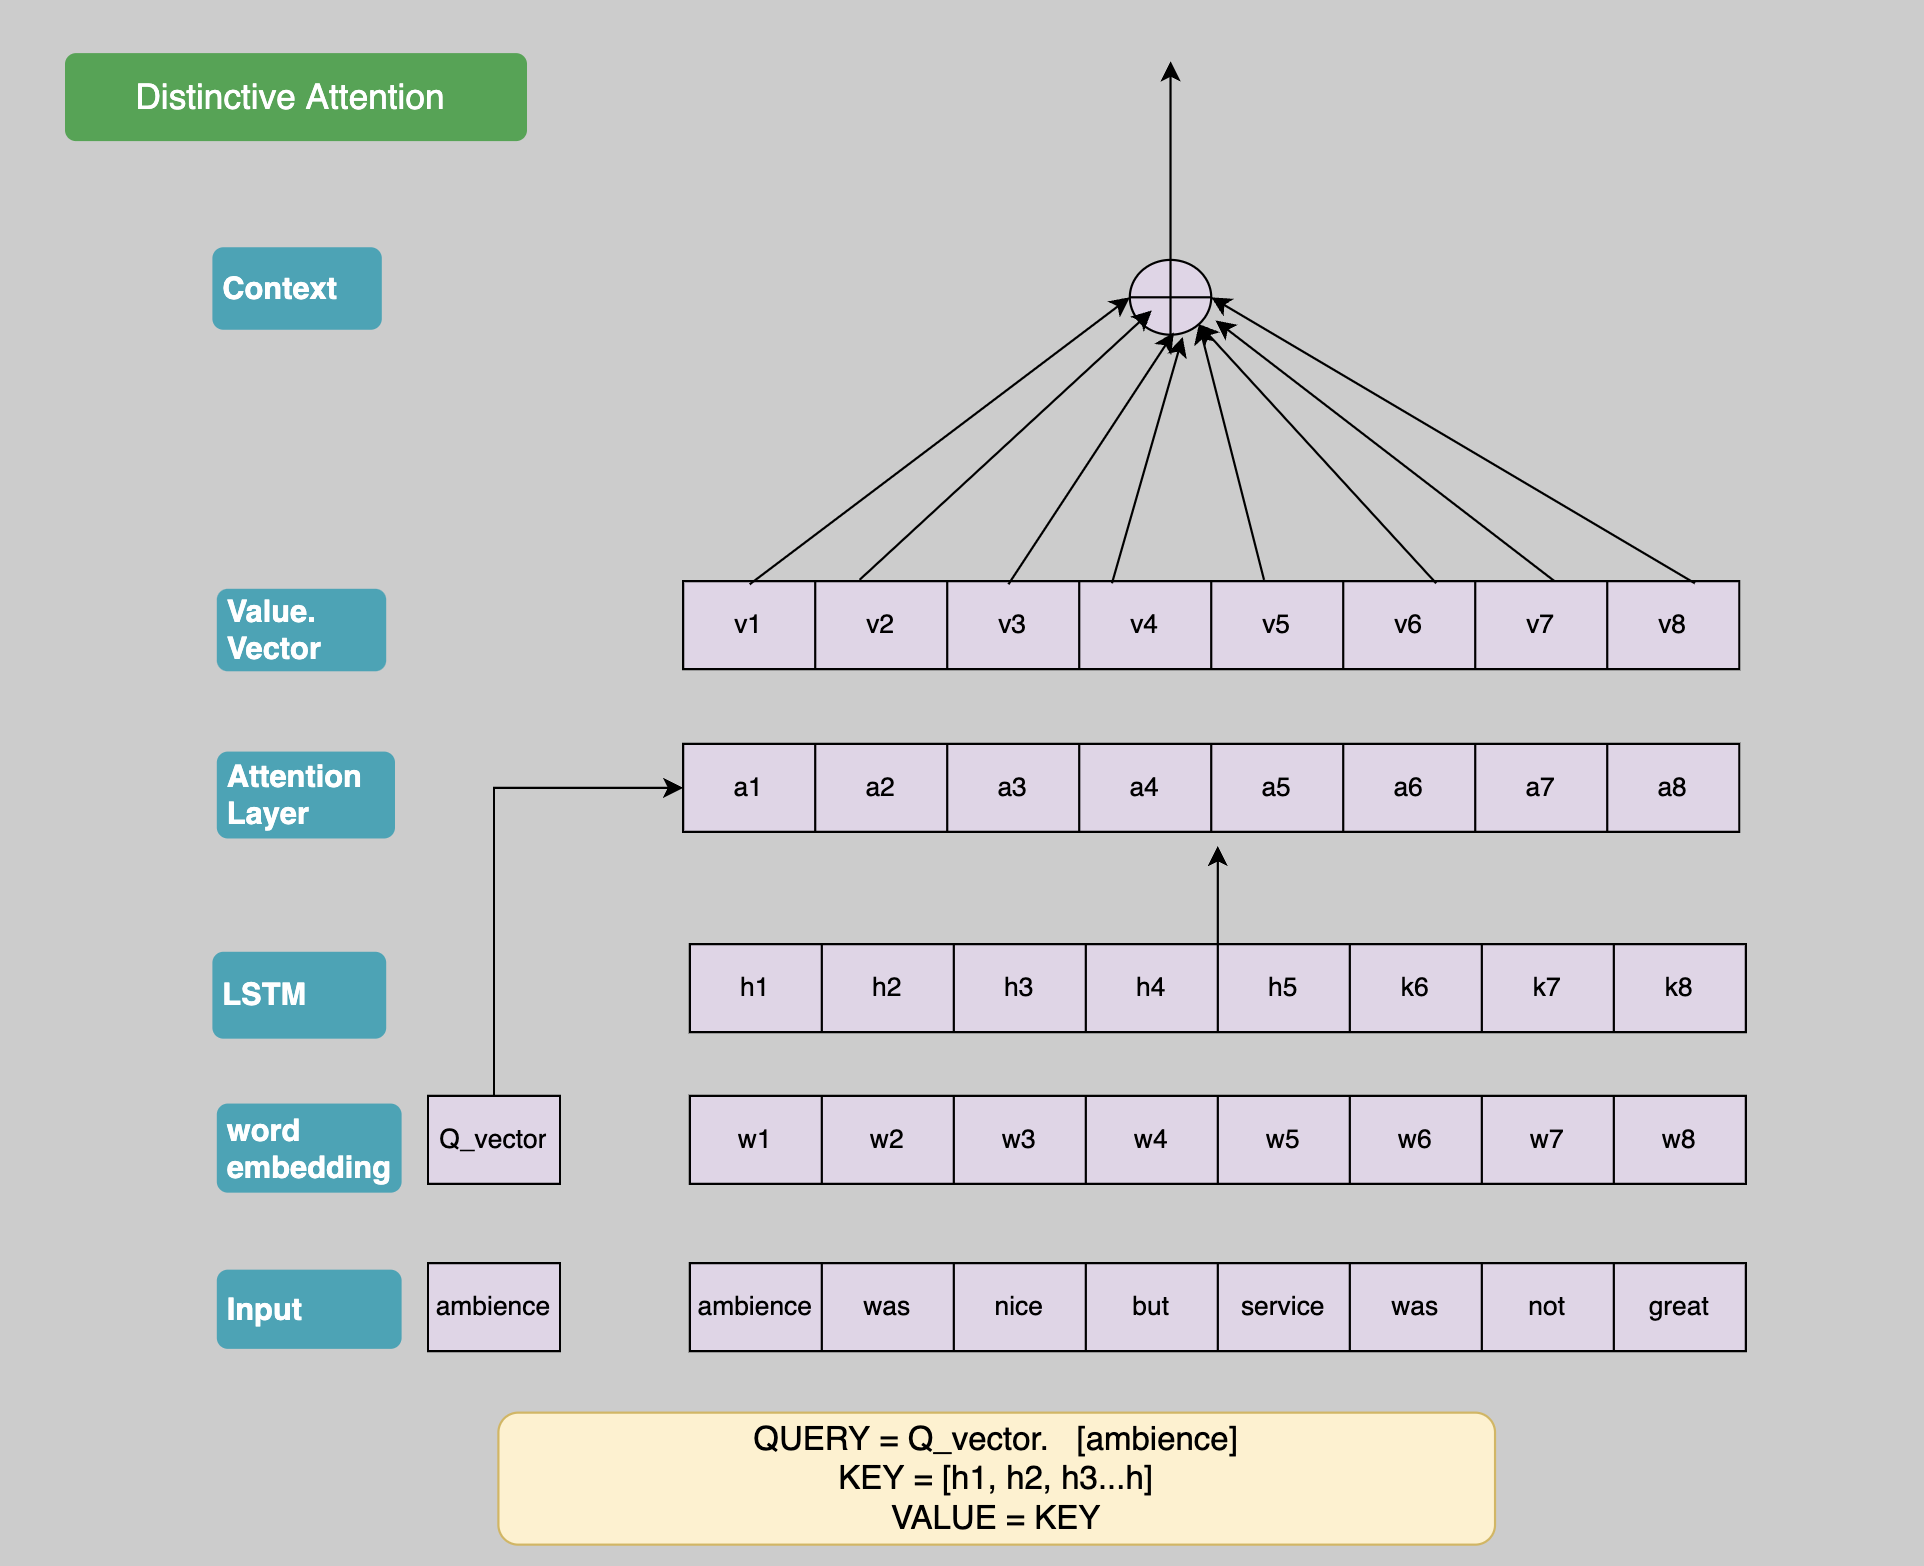


### **2. Self Attention AM**

- In Self-Attention both KEY and QUERY sequence is Same.

- Basically, QUERY = KEY = VALUE

- ###  **How to Compute Self AM?**
  - Compute KEY, QUERY and VALUE Vectors
  - Compute Energy function
  - Compute Attention Score


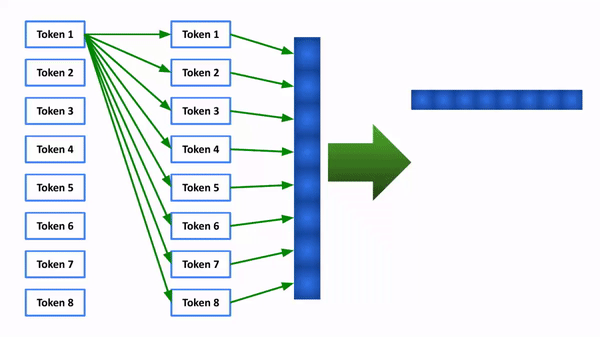

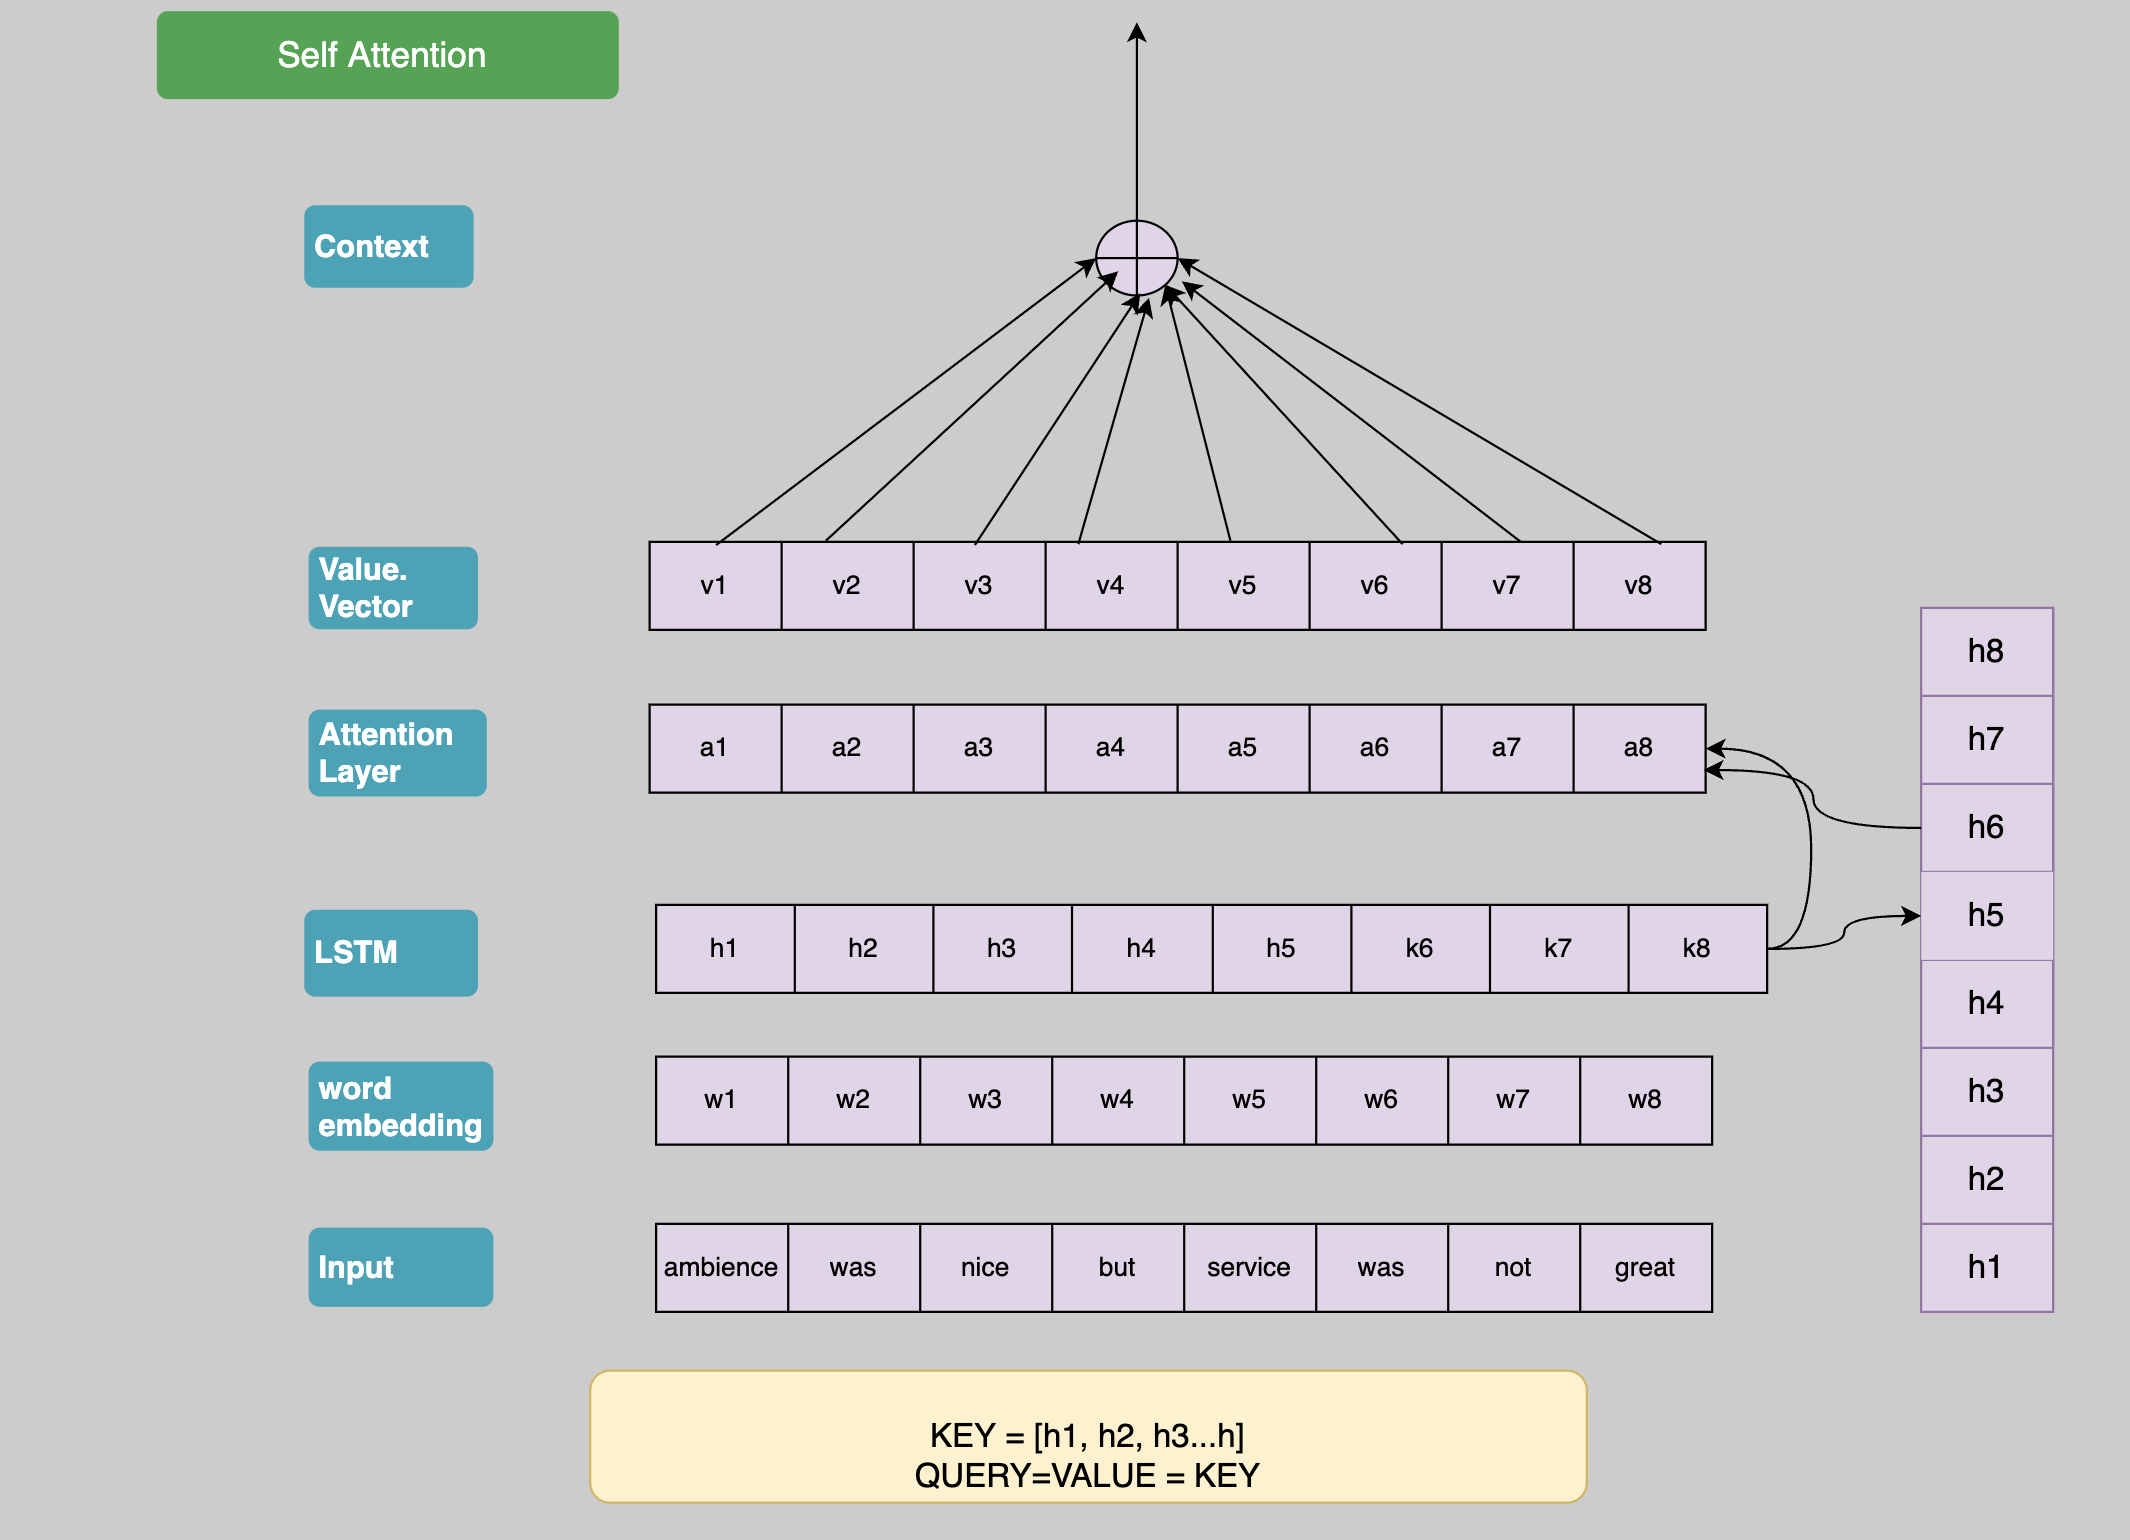

# What are attention mechanisms based on Number of Position?

## **1. Soft Attention Mechanisms**

- In soft attention, we compute attention weight $w_1, w_2, w_3 . . . w_n, \space where \sum W = 1.$
- And, It uses a weighted average of all hidden states of the input sequence
to build the context vector.

 > $z_i =  w_i * v_i, $

  > $C = \sum_{i=1}^{d_k} (z_i), $

- The usage of the soft weighing method makes the neural network
amenable to efficient learning through backpropagation,


- **Pro**: the model is smooth and differentiable.
- **Con**: expensive when the source input is large.


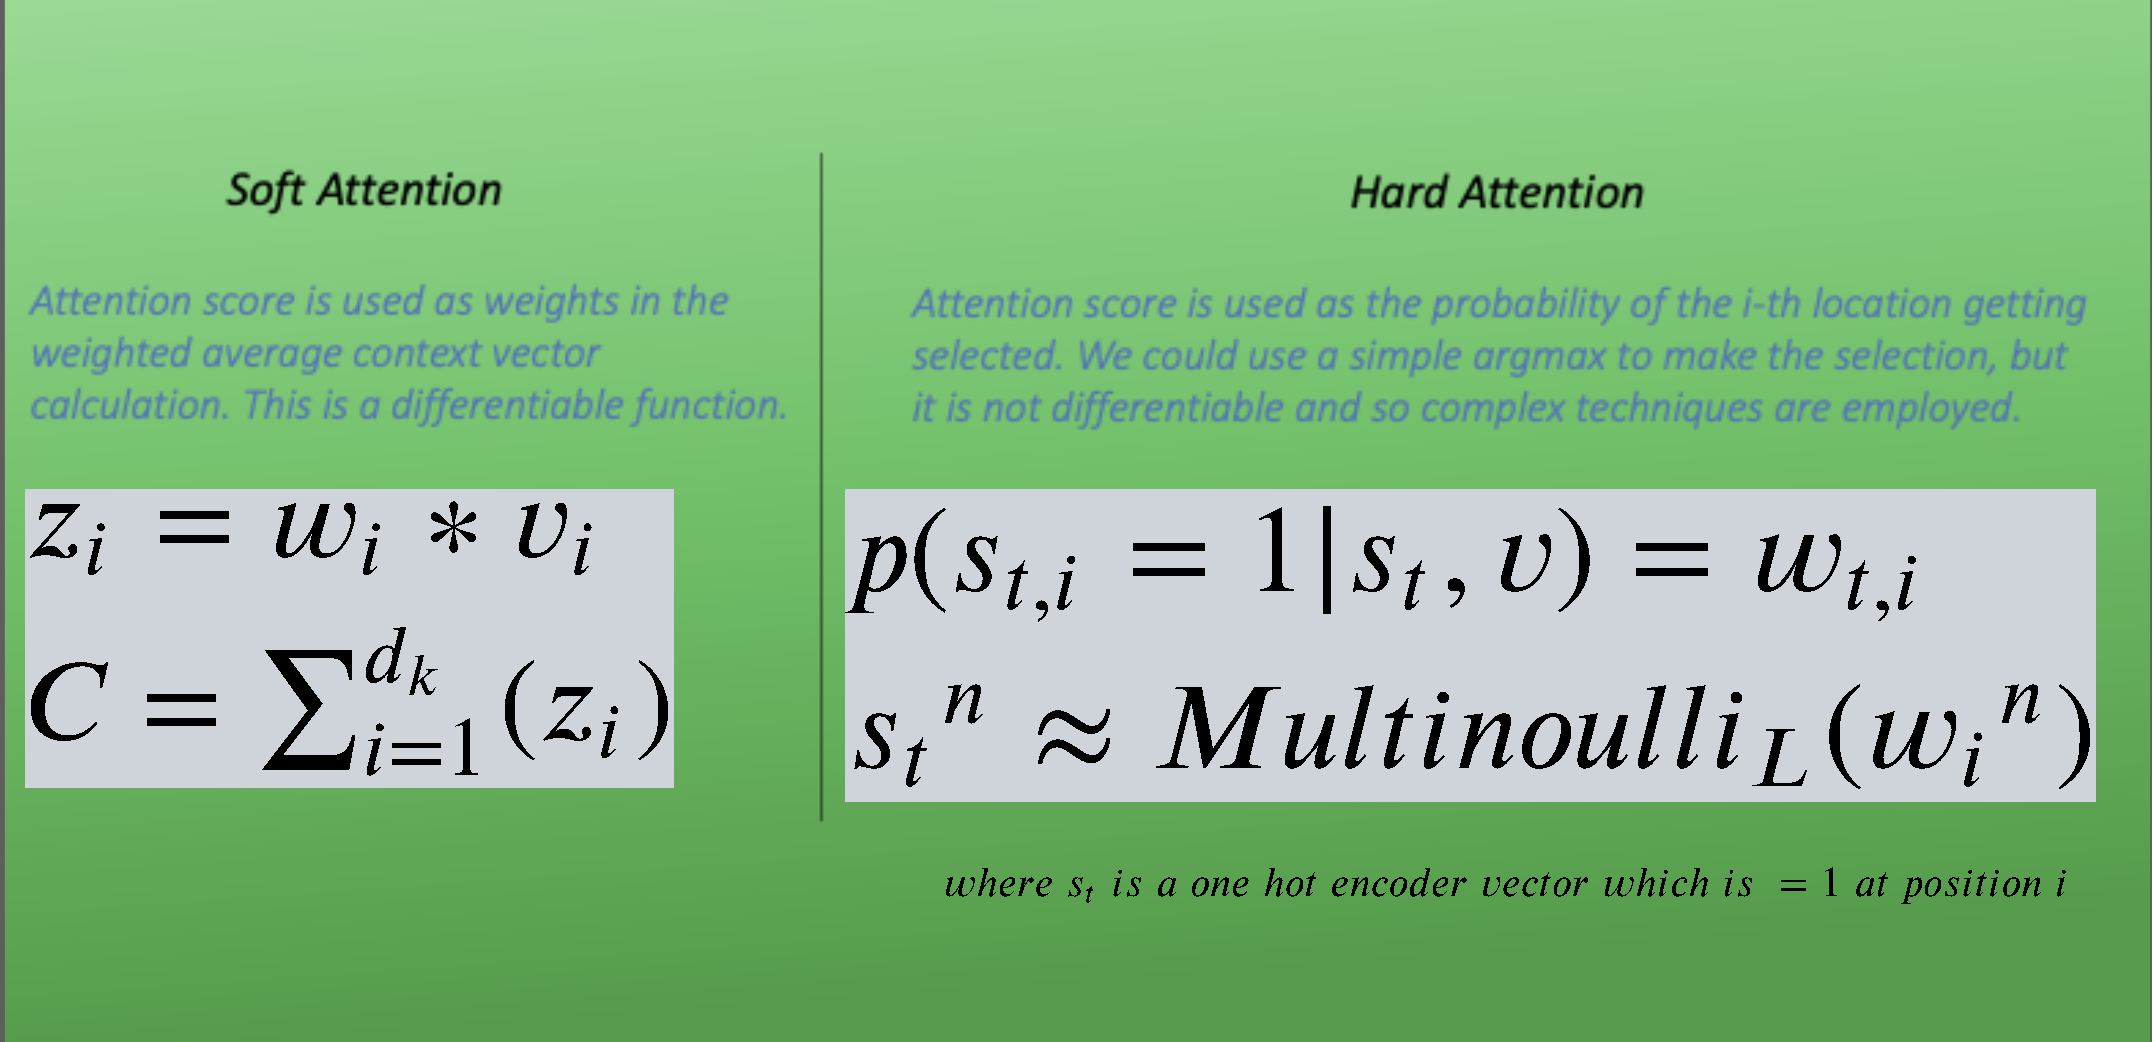

## **2. Hard Attention**

- Calculate attention weights as $w_1, w_2, w_3 . . . w_n$.
- $w_i$  adds up to 1 which can be interpreted as the probability that $v_i$ is the area that we should pay attention to.
- So instead of a weighted average, hard attention uses $w_i$  as a sample rate to pick one $v_i$.

 $ where, \space \space \normalsize v_i \space ϵ \space Value$

-  A value $m ∈ R^1$ is drawn from a multinomial distribution with
$w_1, w_2, w_3 . . . w_n$ as parameters for the probabilities.
- Then, the
context vector is simply defined as follows:
 > $C = V_m  \space \space \space \space \space where, \space V = VALUE $


- **Pro**: less calculation at the inference time.
- **Con**: the model is non-differentiable and requires more complicated techniques such as variance reduction or reinforcement learning to train

# **What are attention mechanisms based on Number of abstraction?**

## **1. Single-Level Attention Mechanisms**

- In the most general case, attention weights are computed only for the original input sequence.
- This
type of attention can be termed as single-level.
- **Example** : Above Attention Implementation is a kind of Single-level-attention.

## **2. Multi-level Attention Mechanisms**


- Attention applied on multiple levels of abstraction of the input sequence in a sequential manner.
- The output (context
vector) of the lower abstraction level becomes the query state for the higher abstraction level.
- **Example** : For the Document Classification,

- Attention applied at two different levels of abstraction, i.e. at word level and sentence level.
- This model is called a “Hierarchical Attention Model"(HAM)
- As it captures the natural hierarchical structure of documents, i.e. a document is made up of sentences and sentences
are made up of words.

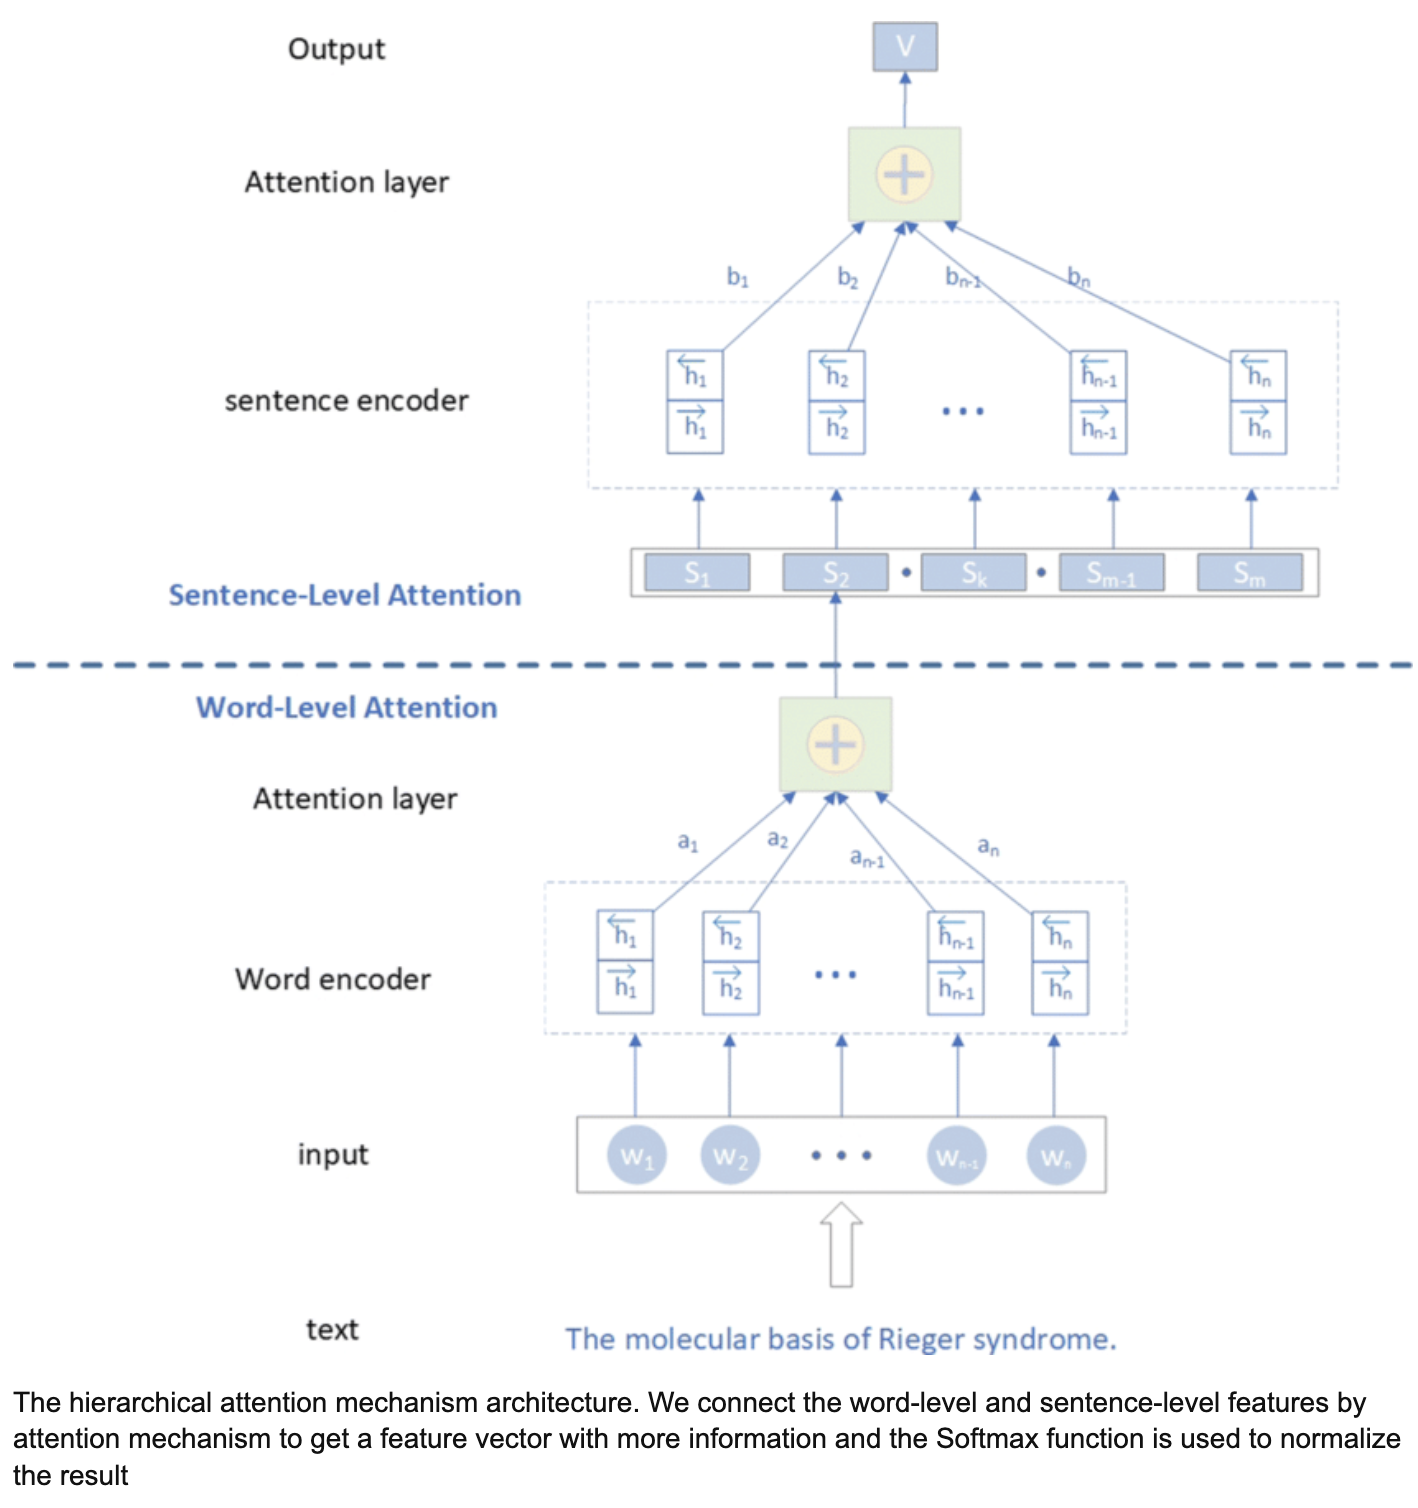

# **What are attention mechanisms based on Number of Representation?**

### **1. Single-Head Attention Mechanisms**

- In the most general case, attention weights are computed only for the original input sequence.

- It may or may not contains trainable parameters.
- like if Energy function is DOT product there is no learning parameters involved.
- But if energy function is MLP, there is learning parameters involved.

- This type of attention can be termed as single-headed, etc.
- **Example** : Above Attention Implementation is a kind of Single-level-attention

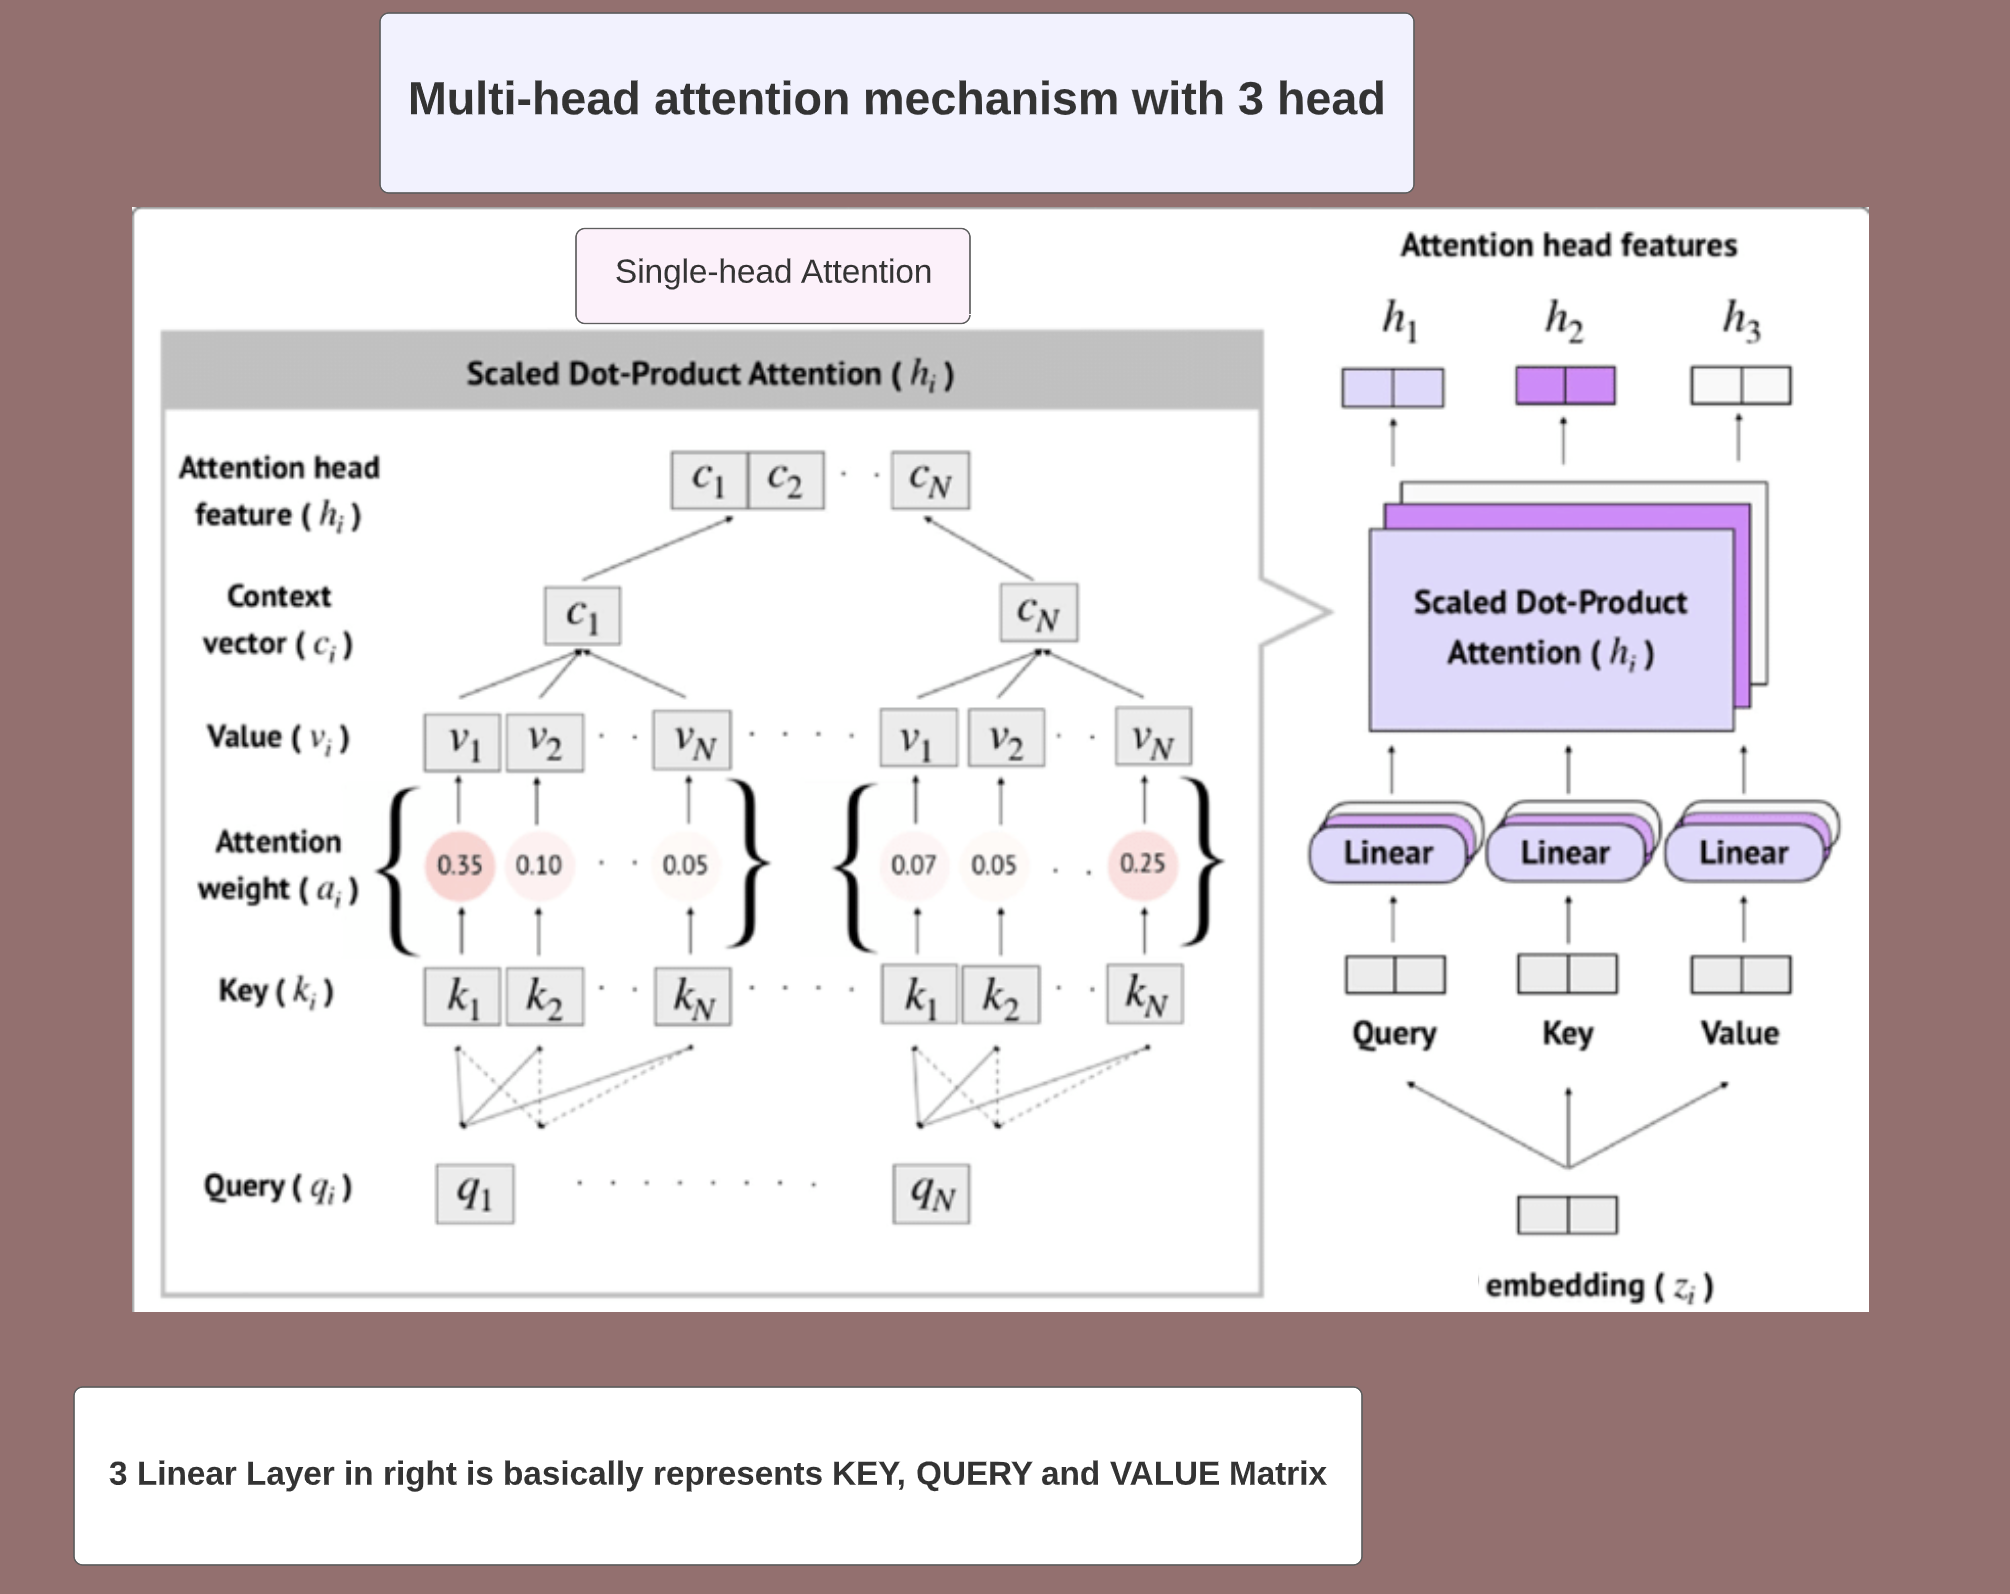

### **2. Multi-headed Attention Mechanisms?**

- Key sequeces can have multiple dependency relation to Query sequences
- i.e. A word in a sequence can have multiple dependency relation to the other word.
- representation of dependency is very much needed to understand syntactic and semantic meaning of sequence.
-Multiple attention heads healps to understand complex relation among the sequence.
- It contains trainable parameters in the from KEY MATRIX, QUERY MATRIX   and VALUE MATRIX.

- **How to Compute Multi-headed AM?**
    1. Randomly intialized wq, wk and wv MATRIX.
    2. Define number of attention head `N`.
    3. Compute Query, Value and Key Matrix by taking Dot product of above three Matrix.
    4. Split each matrix into `N` matrix of shape  (inp_seq_len, depth) each, where depth is nothing but last dimention of above matrix divide by `N`.
    5. For each attention head, Select an energy function and  compute Context vectors
    6. Concat the context vector of all attention head.
    7. pass it through other linear layer.



In [ ]:
from IPython.display import display, HTML
def np_display(x):
  # display dataframe
  df = pd.DataFrame(x)
  display(df)


def scaled_dot_product_attention(vect, mat):
  # Compute scaled dot product attention mechanisms
  return np.matmul(np.transpose(vect), mat)/(len(vect)**2)

paragraph = [
             'food quality was not good as it was not cooked properly',
             ]


paragraph = [para.split(' ') for para in  paragraph]

# target== paragraph as we are computing self attention
target = paragraph

# Word embedding of paragraph text
X = [[glove_vectors[i] for i in para] for para in paragraph]
X = np.stack([pca.transform(i) for i in X], axis= 0).reshape(11, 5)


# word embedding of query text
Y = [glove_vectors[i].tolist() for i in target]
Y = np.stack([pca.transform(i) for i in Y]).reshape(11, 5)

# **Lets Compute one of the popular Multi-headed attention in NLP.**

 - ##   `Multi-headed Self Attention`

### **1. Step-1 Randomly intialized wq, wk and wv MATRIX.**
- Each word in X is represented using a vector of size 5.

- Randomly Initialize 3 matrices, `Wq, Wv, Wk = [5   ✕  9]` matrix

      

In [ ]:
wk = np.ones((5, 9))
wv = np.ones((5, 9))
wq = np.ones( (5, 9))
display(HTML('<h3>WQ</h3>'))
np_display(wq)


### **2. Define number of Attention Head**

- For our task assumes N=3

In [ ]:
N_head = 3

## **3. Compute Query, Value and Key Matrix**

- Three new matrix can be generated by dot product on  each weight matrices with seq_embedding,



$Query \space Matrix = Q =  X • W_q $         
$Key \space Matrix = K     = X • W_k $        
$Value \space Matrix  = V = X • W_v $  

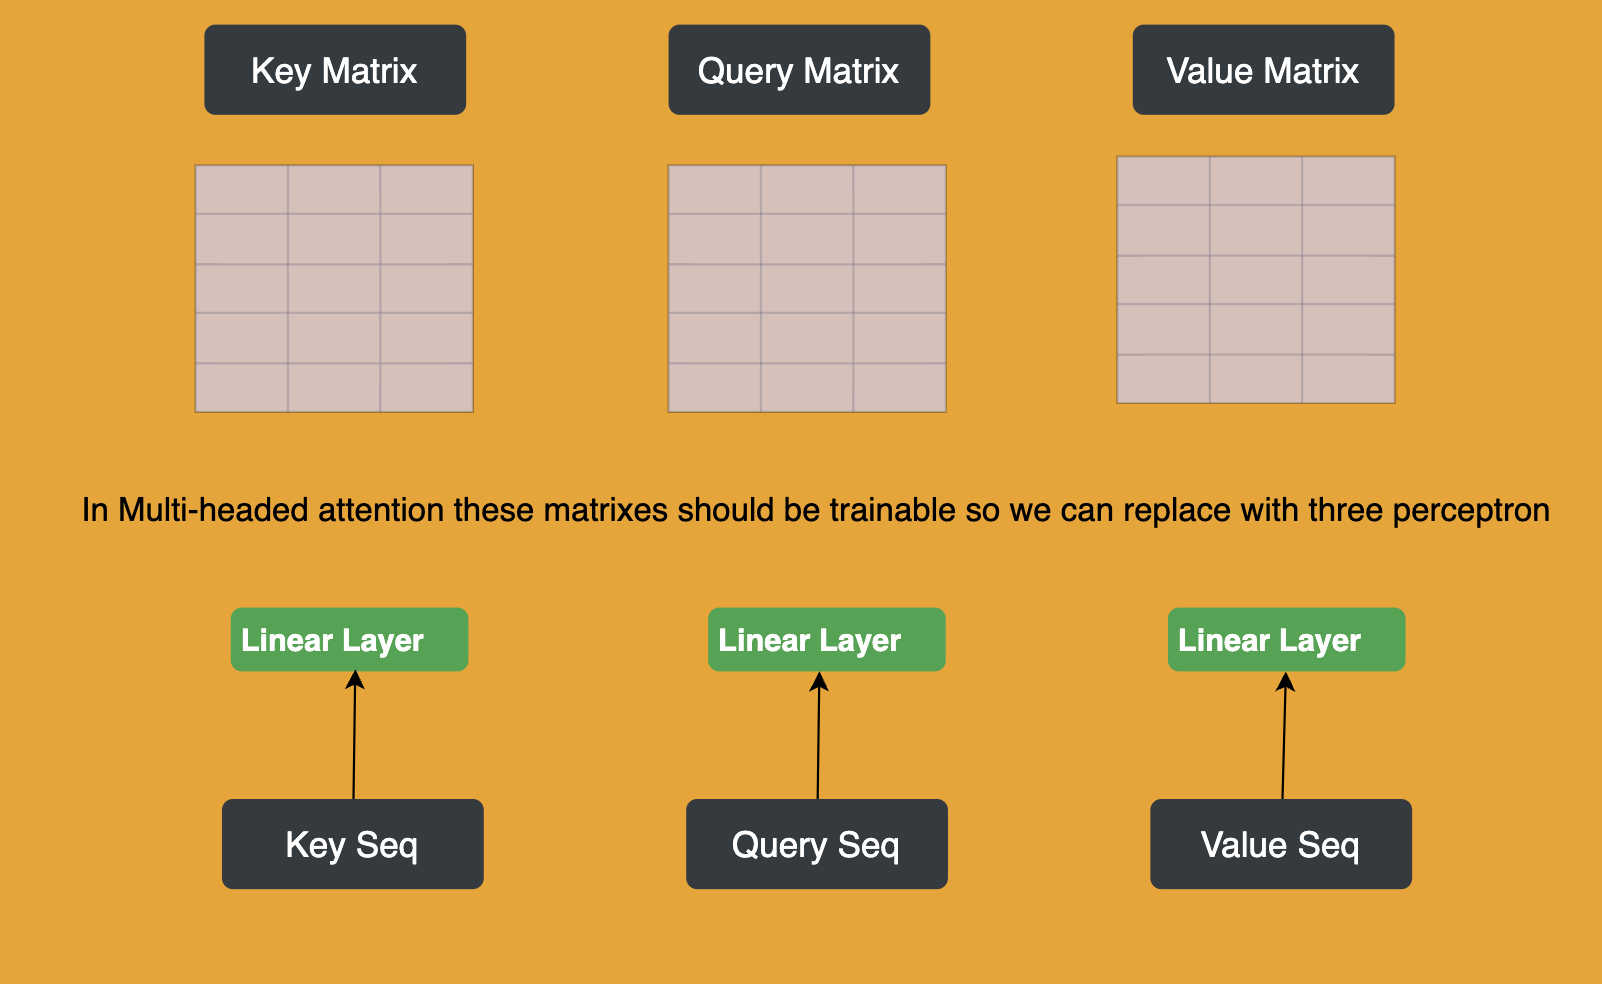

## **4. Split the Matrix**

- Split the matrix into `N` sub-matrix

In [ ]:
KEY_VECTORS = np.matmul(X, wk)
QUERY_VECTORS = np.matmul(X, wq)
VALUE_VECTORS = np.matmul(X, wv)



KEY_MATRIX = np.hsplit(KEY_VECTORS, N_head)
QUERY_MATRIX = np.hsplit(QUERY_VECTORS, N_head)
VALUE_MATRIX = np.hsplit(VALUE_VECTORS, N_head)


display(HTML('<h3>KEY_MATRIX</h3>'))
np_display(KEY_MATRIX[0])

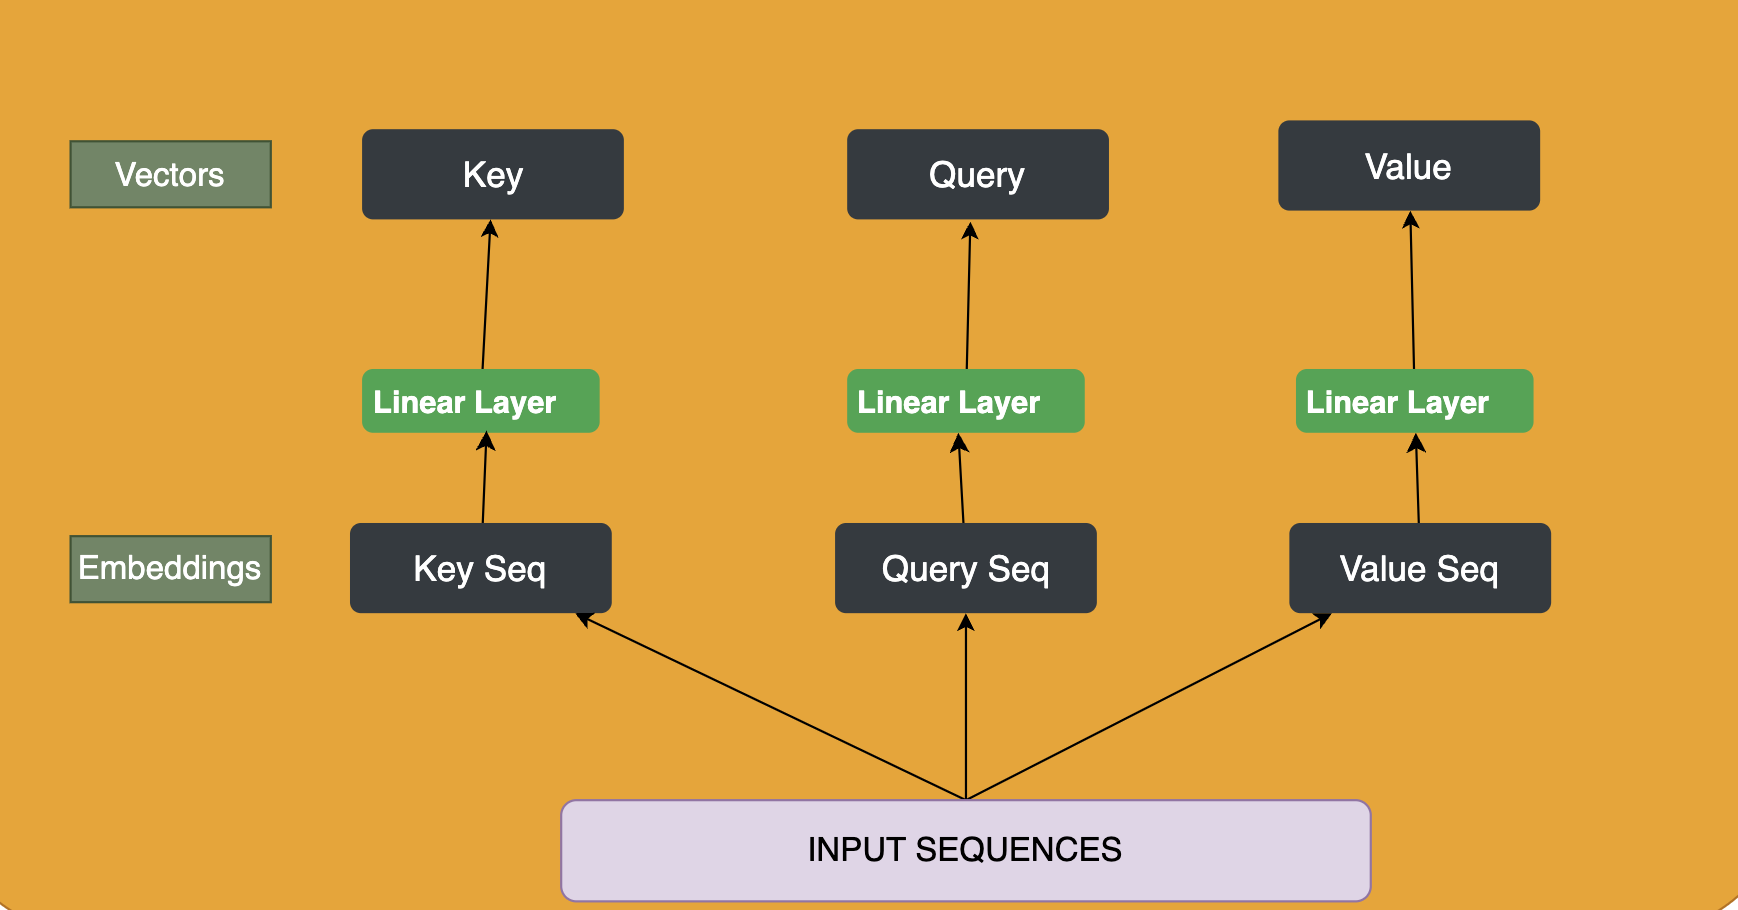

## **5. Select an energy function and Compute Attention Scores.**

- Lets choose an energy function -> `Scaled Dot Product`.
- Using Query, Key and Value Matrix, compute context vector.


  - $ a(Q,K) =  \dfrac{Q.K^T}{\sqrt D}$

  where $Q$ = `QUERY_VECTORS`\
      $K$ = `KEY_VECTORS`\
      $D$ = `Dimension of Input word representation`.

In [ ]:
dot_product = np.matmul(KEY_MATRIX[0].T, QUERY_MATRIX[0])
attention_values = dot_product/(5)**0.5
np_display(attention_values)

## **6. Calculate Context Vector**

- Normalize the weight using `softmax`.
- Return DOT Product of attention score and Value Vector

$In \space below \space Diagram, Q= Query,$\
$K= Key, $\
$V=Value,$\
$ where \space  \space K==Q==V \space $ \\
and
$ d_k $ is embedding dimension of input word

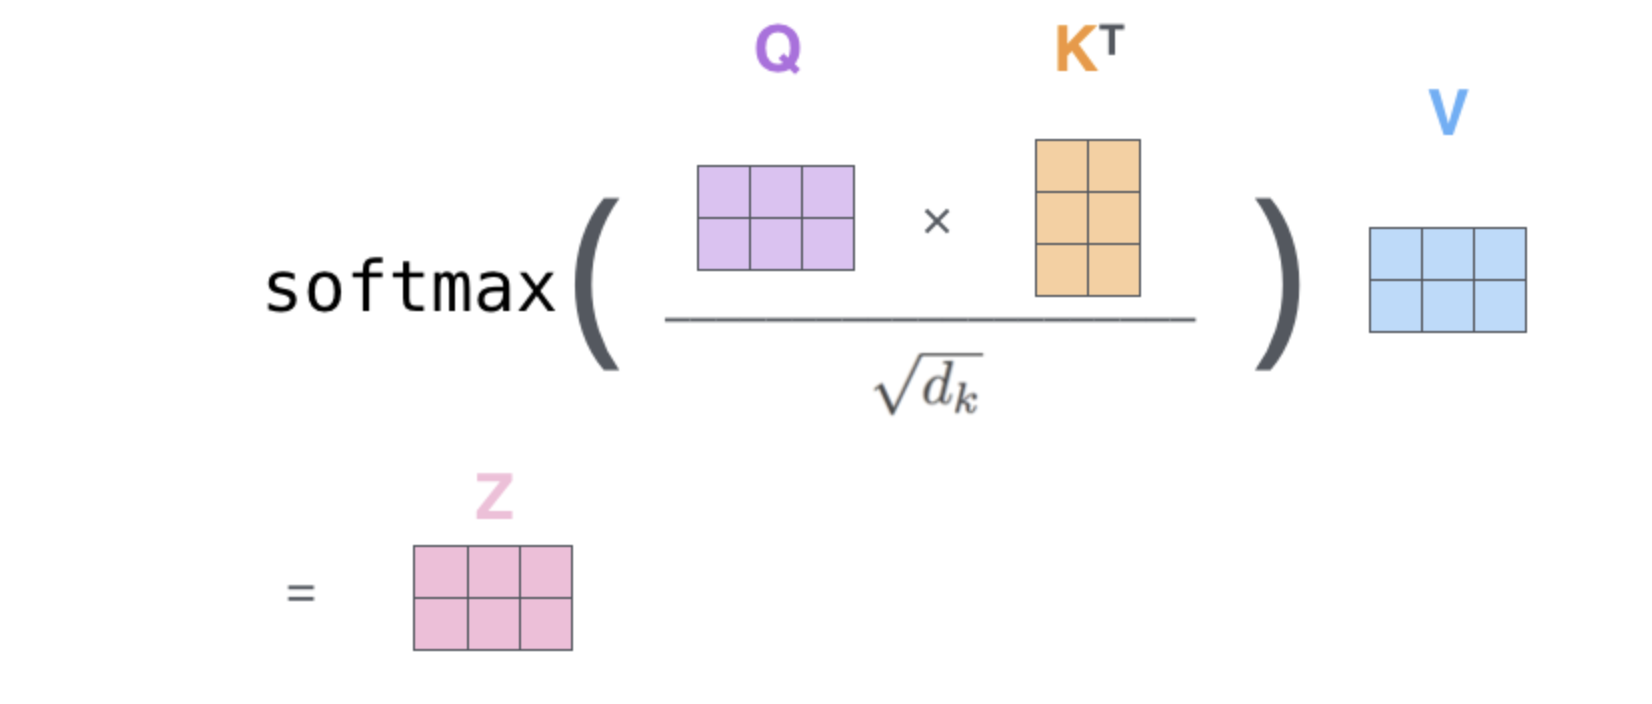

In [ ]:
#softmaxing
attention_value = np.array(attention_values, dtype=np.float64)
e_x = np.exp(attention_value)
attention_score =  e_x / e_x.sum(axis=0)

#concate context vector
context_vector = np.matmul(VALUE_MATRIX[0], attention_score.T)
display(pd.DataFrame(context_vector))

## **7. Compute Multi-headed Context Vector For N_Head**

- $Z = concat(context\_vector1, context\_vector2, context\_vector3)$
- where , $context\_vector1 = z_0, context\_vector2 = z_1, context\_vector3=z_3$


## **Multi-headed computation Flow**

In [ ]:
z = []

#step-1
KEY_MATRIX = np.ones((5, 9))
VALUE_MATRIX = np.ones((5, 9))
QUERY_MATRIX = np.ones( (5, 9))

#step-2
N_head = 3

#step-3
KEY_VECTORS = np.matmul(X, wk)
QUERY_VECTORS = np.matmul(X, wq)
VALUE_VECTORS = np.matmul(X, wv)


# step-4
KEY_MATRIX = np.hsplit(KEY_VECTORS, N_head)
QUERY_MATRIX = np.hsplit(QUERY_VECTORS, N_head)
VALUE_MATRIX = np.hsplit(VALUE_VECTORS, N_head)


# Compute context vector for N-head
for i in range(N_head):

  #step-5
  dot_product = np.matmul(KEY_MATRIX[i].T, QUERY_MATRIX[i])
  attention_values = dot_product/(5)**0.5


  attention_values = np.array(attention_values, dtype=np.float64)
  e_x = np.exp(attention_values)
  attention_score =  e_x / e_x.sum(axis=0)

  #step-6
  context_vector = np.matmul(VALUE_MATRIX[i] , attention_score.T )
  z.append(context_vector)

# step-7
context_vectors = np.hstack(z)

## **ViSUALIZATION OF MULTIHEAD ATTENTION COMPUTATION**

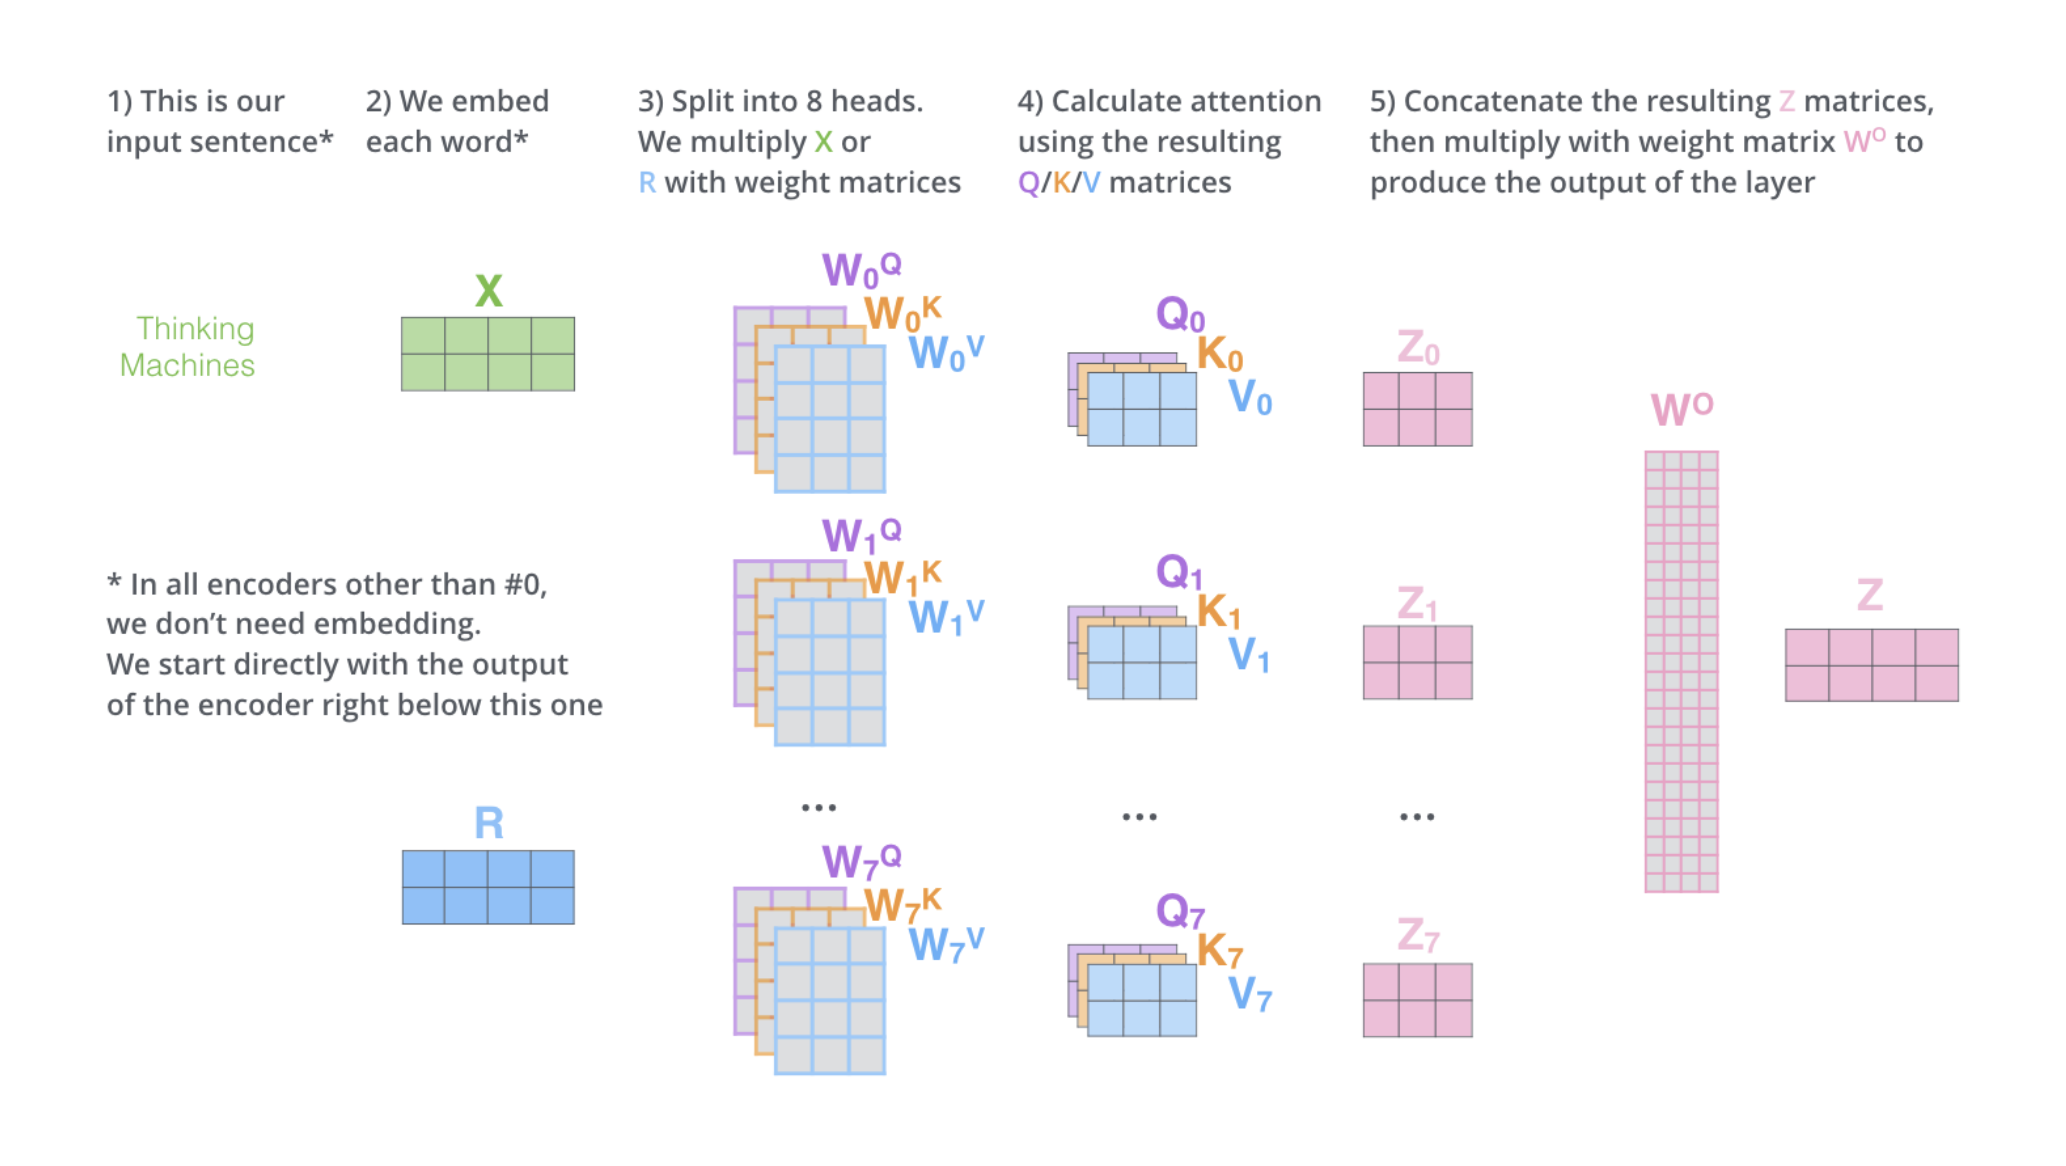

# **Why it is popular and what is its significance?**
In a single self-attention operation, all this information just gets summed together.


*  Multi-head attention helps to learn diverse syntactic relations in a given input sequence.
*   provides greater power of discrimination, by combining several self attention mechanisms each with different matrices $W_{iq}, W_{iv}, W_{ik}$



## **Below showing attention heatmap of "it" word at different attention head.**



- for simplicity, assume we have two attention head,
- Two attention head shown in below diagram as green and brown heatmap.
- 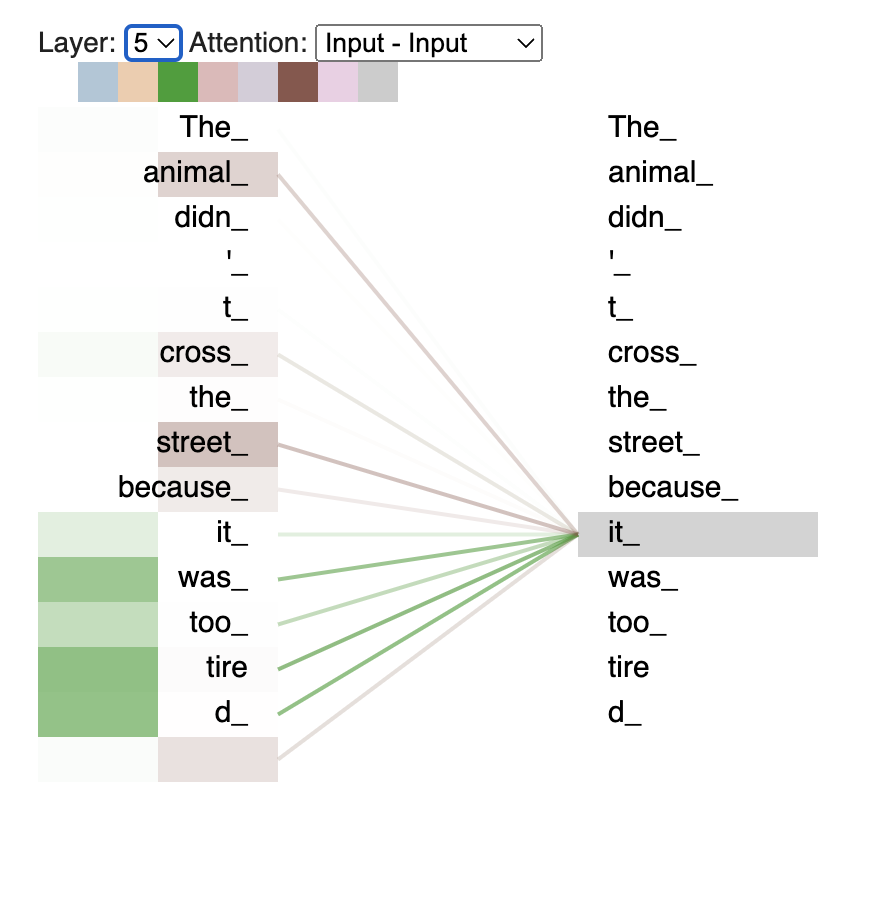


You Can See, one attention head is focusing on the "animal" portion,
while other attention head is fousing on "tired" portion of sentence.

So basically different attention head learns different relation among the words.






# **Code Implementation**

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization
import gensim.downloader as api
from tensorflow.keras.layers import Embedding
import numpy as np

tf.random.set_seed(123)

## **DOWNLOAD THE DATASET**

In [ ]:
# Downloasd dataset

!gdown https://drive.google.com/file/d/1DNgciEZTQWuo_wq4qMGIV8z3VC1Onjjv/view?usp=share_link --fuzzy
!gdown https://drive.google.com/file/d/1ePfUhb2XeicnybAMu0y2w3BhiWm4XY8t/view?usp=share_link --fuzzy
!gdown https://drive.google.com/file/d/1FRn6Gn3ijmCWfhUI6QkGm4g4LeQ7Veg0/view?usp=share_link --fuzzy
!gdown https://drive.google.com/file/d/1Fw3yivW_PSH-C5T_4-9bWshxPHxvxtAi/view?usp=share_link --fuzzy
!gdown https://drive.google.com/file/d/1F9r26d7emj43EG6kcMfvOsu1rI8yxR4d/view?usp=share_link --fuzzy
!gdown https://drive.google.com/file/d/1zSYr8akNxtCCR_TxVIFrel1k254k-vin/view?usp=share_link --fuzzy
!gdown https://drive.google.com/file/d/1zSYr8akNxtCCR_TxVIFrel1k254k-vin/view?usp=share_link --fuzzy
!gdown https://drive.google.com/file/d/1zSYr8akNxtCCR_TxVIFrel1k254k-vin/view?usp=share_link --fuzzy
!gdown https://drive.google.com/file/d/1I0vjwcnwfaMZdwhS-oJjqUoihl9NxZ1g/view?usp=share_link --fuzzy
!gdown https://drive.google.com/file/d/1tX9mZBStZGCQmOhgaCu-tSdlXqQU77ou/view?usp=share_link --fuzzy
!gdown https://drive.google.com/file/d/1-GNcBpiB3Y0RzbJLawxL31IjkTBtpUz2/view?usp=share_link --fuzzy

## **DATA LOADING**

In [ ]:
def load_mams_data(path):
  df = pd.read_csv(path)
  df = df[['text', 'term', 'polarity']]
  return df

def load_laptop_data(path):
  text_ds = []
  term_ds = []
  polarity_ds = []
  with open(path, 'r') as f:
    data = f.read().splitlines()

  terms = []
  polarities = []
  text = ""
  term = ""
  polarity = ""
  for row in data[2:]:
    # We are on new text column
    if len(row) == 1:
      if term != "":
        terms.append(term)
        polarities.append(polarity)
      for i in range(len(terms)):
        text_ds.append(text.strip())
        term_ds.append(terms[i].strip())
        polarity_ds.append(polarities[i])

      text = ""
      term = ""
      polarity = ""
      terms = []
      polarities = []

    else:
      token, label = row.rsplit(',', 1)
      text += " " + token

      if label == 'T-POS':
        label = 'positive'
      elif label == 'T-NEG':
        label = 'negative'
      elif label == 'T-NEU':
        label = 'neutral'
      else:
        if term != "":
          terms.append(term)
          polarities.append(polarity)
        term = ""
        polarity = ""
        continue

      if polarity == label:
        term += " " + token

      else:
        if term != "":
          terms.append(term)
          polarities.append(polarity)

        polarity = label
        term = token

  df = pd.DataFrame()
  df['text'] = text_ds
  df['term'] = term_ds
  df['polarity'] = polarity_ds
  return df

In [ ]:
import pandas as pd
# laptop dataset
laptop_train, laptop_test, laptop_valid = list(map(load_laptop_data, ['laptop_train.csv', 'laptop_test.csv', 'laptop_dev.csv']))

# restaurant dataset
rest_train, rest_test, rest_valid = list(map(load_laptop_data, ['rest16_train.csv', 'rest16_test.csv', 'rest16_dev.csv']))

# mams dataset
mams_train, mams_test, mams_valid = list(map(load_mams_data, ['mams_train.csv', 'mams_test.csv', 'mams_val.csv']))

# dataset combined, shuffled
train_data = pd.concat([laptop_train, rest_train, mams_train, laptop_test, rest_test, mams_test]).sample(frac = 1).reset_index(drop = True)
valid_data = pd.concat([laptop_valid, rest_valid, mams_valid]).sample(frac = 1).reset_index(drop = True)

In [ ]:
print('*'*30,'data ', '*'*30)
train_data.head()

In [ ]:
print('*'*30,'data uniqueness', '*'*30)
train_data.nunique()

In [ ]:
print('*'*30,'Sentiment labels', '*'*30)
train_data['polarity'].value_counts()

## Sampling train data to contain equal values of polarities

In [ ]:
train_data = train_data[train_data['polarity'] != 'neutral']

In [ ]:
valid_data = valid_data[valid_data['polarity'] != 'neutral']

In [ ]:
# data processing, encoding labels, and lower casing the sentence text and aspect text

pol2idx = { 'positive' : 1, 'negative' : 0}
for data in [train_data, valid_data]:
  data['polarity'] = data['polarity'].apply(lambda x:pol2idx[x])
  data['text'] = data['text'].apply(lambda x: x.lower())
  data['term'] = data['term'].apply(lambda x: str(x).lower()).astype('str')

  data = data.drop_duplicates(["text", "term", "polarity"])

train_data.head()

## **Embedding Model Initialization**
- using Word2Vec as [Word2Vec typically performs better than fasttext for semantic tasks](https://github.com/RaRe-Technologies/gensim/blob/develop/docs/notebooks/Word2Vec_FastText_Comparison.ipynb)

In [ ]:
# load word embeddings from gensim api

word2vec = api.load("word2vec-google-news-300")

In [ ]:
embedding_dim = 300

In [ ]:
tokenizer = tf.keras.preprocessing.text.Tokenizer(lower=True)
tokenizer.fit_on_texts(train_data['text'])

In [ ]:
import gc
num_tokens = len(tokenizer.word_index) + 1
hits = 0
misses = 0


# Prepare embedding matrix
embedding_matrix = np.zeros((num_tokens, embedding_dim))
for word, i in tokenizer.word_index.items():
    embedding_vector = None
    try:
      embedding_vector = word2vec[word]
    except Exception :
      pass

    if embedding_vector is not None:
        # Words not found in embedding index will be all-zeros.
        # This includes the representation for "padding" and "OOV"
        embedding_matrix[i] = embedding_vector
        hits += 1
    else:
        misses += 1

del word2vec
gc.collect()
print("Converted %d words (%d misses)" % (hits, misses))

## **Train and Val set Preparartion**

In [ ]:
def tokenize_and_pad_text(text, seq_len):
  tokens = tokenizer.texts_to_sequences([text])
  padded_tokens = tf.keras.preprocessing.sequence.pad_sequences(tokens, maxlen=seq_len)
  return padded_tokens[0]

In [ ]:
def prepare_and_tokenize_dataset(dataset):
  all_texts = []
  all_terms = []
  all_polarities = []
  for idx, row in dataset.iterrows():
    all_texts.append(tokenize_and_pad_text(row['text'], 128))
    all_terms.append(tokenize_and_pad_text(row['term'], 4))
    all_polarities.append(row['polarity'])

  all_texts = tf.constant(all_texts)
  all_terms = tf.constant(all_terms)
  all_polarities = tf.constant(all_polarities)

  return (all_texts, all_terms, all_polarities)

train_texts, train_terms, train_polarities = prepare_and_tokenize_dataset(train_data)
valid_texts, valid_terms, valid_polarities = prepare_and_tokenize_dataset(valid_data)

# Here's our training data, padded to the right

In [ ]:
print("*"*64)
print("Review text", train_texts[0])
print("*"*64)
print("Aspect text", train_terms[0])
print("*"*64)
print("Polarity", train_polarities[0])
print("*"*64)

## **ATTENTION LAYER IMPLEMENTATION**

In [ ]:
# Attention Mechanisms Implementation in Keras

class Attention(tf.keras.layers.Layer):
  def __init__(self, units):
    super(Attention, self).__init__(name='attention')
    self.units = units
    self.supports_masking = True
    self.K = tf.keras.layers.Dense(self.units)
    self.Q = tf.keras.layers.Dense(self.units)
    self.V = tf.keras.layers.Dense(1)

    self.debug = False

  def get_config(self):

    config = super().get_config().copy()
    config.update({'units': self.units, })
    return config

  def compute_mask(self, keys, keys_mask):
    """
    Output will be values of shape (batch_size, keys_seq_len)
    So, it's mask will be keys_mask
    """
    return keys_mask


  def apply_mask_to_scores(self, scores, keys_mask, queries_mask):


    keys_mask = tf.cast(keys_mask, dtype = 'float32')
    queries_mask = tf.cast(queries_mask, dtype = 'float32')

    keys_mask = tf.expand_dims(keys_mask, axis = -1)
    queries_mask = tf.expand_dims(queries_mask, axis = -2)
    scores_mask = keys_mask * queries_mask

    # Ignoring masked scores
    if self.debug:
        print(scores_mask)

    # Normalizing scores
    scores, _ = tf.linalg.normalize(scores)

    return scores * scores_mask

  def call(self, keys, keys_mask, queries, queries_mask):
    """
    keys: Tensor of shape (batch_size, 128, embed_dim): Review embeddings
    queries: Tensor of shape (batch_size, 4, embed_dim): Aspect embeddings
    """

    queries = self.Q(queries)
    keys = self.K(keys)
    values = self.V(keys)

    queries = tf.transpose(queries, (0, 2, 1))

    score = tf.matmul(keys, queries)

    # Masking
    score = self.apply_mask_to_scores(score, keys_mask, queries_mask)
    score = score[:, :, -1] # Only considering last query token

    # attention_weights shape == (batch_size, max_length, 4)
    attention_weights = tf.nn.softmax(score, axis = 1)
    attention_weights = tf.expand_dims(attention_weights, axis = -1)

    # context_vector shape after sum == (batch_size, hidden_size)
    context_vector = attention_weights * values

    context_vector = context_vector[:, :, -1]
    attention_weights = attention_weights[:, :, -1]
    return context_vector, attention_weights

## **MODEL ARCHITECTURE**

In [ ]:
class AttnModel(tf.keras.Model):
  def __init__(self, review_input_Shape, aspect_input_shape, num_aspects = 30):
    super().__init__()
    self.num_aspects = num_aspects

    self.embedding_layer = Embedding(
      num_tokens,
      embedding_dim,
      embeddings_initializer=tf.keras.initializers.Constant(embedding_matrix), # Initialize with word2vec embeddings
      name = 'embedding_layer',
      mask_zero=True
    )

    self.review_gru = tf.keras.layers.GRU(256, return_sequences = True)

    self.aspect_gru = tf.keras.layers.GRU(256, return_sequences = True)

    self.attn = Attention(256)

    self.feedforward = tf.keras.layers.Dense(64, activation = "relu")

    self.classifier = tf.keras.layers.Dense(1, activation="sigmoid")

    self.past_attn_weights = None # For visualization

    self.loss_fn = tf.keras.losses.BinaryCrossentropy()

    self.acc_metric = tf.keras.metrics.BinaryAccuracy()


  def call(self, inputs, training = None):
    try:
        review_inputs, aspect_inputs, polarities = inputs
    except ValueError:
        review_inputs, aspect_inputs = inputs
        polarities = None

    review_embeddings = self.embedding_layer(review_inputs)
    review_mask = self.embedding_layer.compute_mask(review_inputs)

    review_embeddings = self.review_gru(review_embeddings, mask = review_mask)

    aspect_embeddings = self.embedding_layer(aspect_inputs)
    aspect_mask = self.embedding_layer.compute_mask(aspect_inputs)

    aspect_embeddings = self.aspect_gru(aspect_embeddings, mask = aspect_mask)

    values, self.past_attn_weights = self.attn(review_embeddings, review_mask, aspect_embeddings, aspect_mask)

    outputs = self.feedforward(values)
    outputs = self.classifier(outputs)

    if polarities is not None:
        loss = self.loss_fn(polarities, outputs)
        self.add_loss(loss)
        self.add_metric(self.acc_metric(polarities, outputs))
    else:
        return outputs

In [ ]:
model = AttnModel(128, 4)

## **MODEL Compiling**

In [ ]:
learning_rate = tf.keras.optimizers.schedules.PolynomialDecay(1e-2, 236, 1e-4)

model.compile(
    optimizer=tf.optimizers.Adam(learning_rate)
)

save_model = tf.keras.callbacks.ModelCheckpoint(filepath='aspect_based_sa.h5',
  monitor='val_binary_accuracy',
  mode='max',
  save_weights_only=True,
  save_best_only=True,
  verbose=1
)

es = tf.keras.callbacks.EarlyStopping(monitor='val_binary_accuracy', mode='max', verbose=1, patience=4)

callbacks = [save_model, es]

## **TRAINING**

In [ ]:
history = model.fit(
  x = [train_texts, train_terms, train_polarities],
  batch_size=32,
  epochs=5,
  validation_data=([valid_texts, valid_terms, valid_polarities], None),
  callbacks=callbacks,
)

Epoch 1/5
339/339 [==============================] - ETA: 0s - loss: 0.4893 - binary_accuracy: 0.7582
Epoch 1: val_binary_accuracy improved from -inf to 0.80904, saving model to aspect_based_sa.h5
339/339 [==============================] - 170s 455ms/step - loss: 0.4893 - binary_accuracy: 0.7582 - val_loss: 0.4290 - val_binary_accuracy: 0.8090
Epoch 2/5
339/339 [==============================] - ETA: 0s - loss: 0.3462 - binary_accuracy: 0.8477
Epoch 2: val_binary_accuracy did not improve from 0.80904
339/339 [==============================] - 123s 362ms/step - loss: 0.3462 - binary_accuracy: 0.8477 - val_loss: 0.4303 - val_binary_accuracy: 0.8081
Epoch 3/5
339/339 [==============================] - ETA: 0s - loss: 0.3325 - binary_accuracy: 0.8535
Epoch 3: val_binary_accuracy did not improve from 0.80904
339/339 [==============================] - 118s 348ms/step - loss: 0.3325 - binary_accuracy: 0.8535 - val_loss: 0.4321 - val_binary_accuracy: 0.8017
Epoch 4/5
339/339 [=================

# Plot the train and validation accuracies

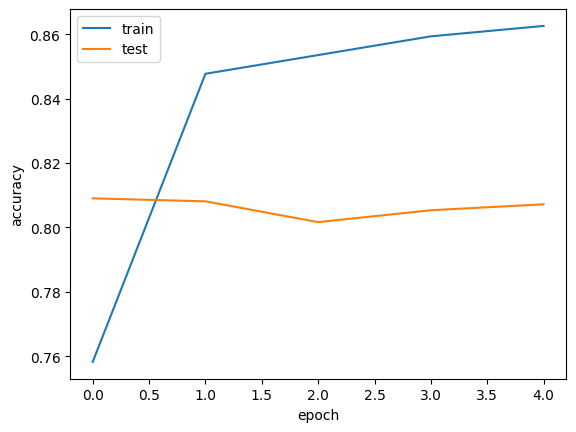

In [ ]:
from matplotlib import pyplot

pyplot.plot(history.history['binary_accuracy'], label='train')
pyplot.plot(history.history['val_binary_accuracy'], label='test')
pyplot.xlabel("epoch")
pyplot.ylabel("accuracy")
pyplot.legend()
pyplot.show()

## **Inferencing**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

label_map = {
    0:'Negative',
    1: 'Positive'
}
def predict_aspect(model, review_text, aspect_text):
  review_tokens = tokenizer.texts_to_sequences([review_text])
  review_tokens = tf.keras.preprocessing.sequence.pad_sequences(review_tokens, maxlen=128)

  aspect_tokens = tokenizer.texts_to_sequences([[aspect_text]])
  aspect_tokens = tf.keras.preprocessing.sequence.pad_sequences(aspect_tokens, maxlen=4)
  preds = model([review_tokens, aspect_tokens])
  neg_prob = preds[0].numpy().item()
  probs = [neg_prob, 1 - neg_prob]
  attn_weights = model.past_attn_weights
  attn_weights = tf.reshape(attn_weights, (128, 1)).numpy()
  attn_weights = attn_weights[-len(review_text.split()):]

  return probs, attn_weights

def print_aspect(probs, attn_weights, review_text, aspect_text):
  print('Review text : ', review_text)
  print('*'*32,f'aspect-term : {aspect_text}', '*'*32)

  predicted_aspect = label_map[np.argmax(probs)]
  print("*"*32, "Predicted Aspect", "*"*32)
  print("*"*32, predicted_aspect, "*"*32)
  plt.figure(figsize=(10.5, 7.5))
  query_df = pd.DataFrame(attn_weights, index = review_text.split(), columns = [aspect_text])
  ax = sns.heatmap(query_df, annot=True, cmap=sns.light_palette("blue", as_cmap=True, ), linewidths=1, ).set_title('predicted')
  plt.show()
  print("\n"*4)

Review text :  The atmosphere of the place was so enchanting and captivating that it made me feel relaxed and happy.
******************************** aspect-term : atmosphere ********************************
******************************** Predicted Aspect ********************************
******************************** Negative ********************************


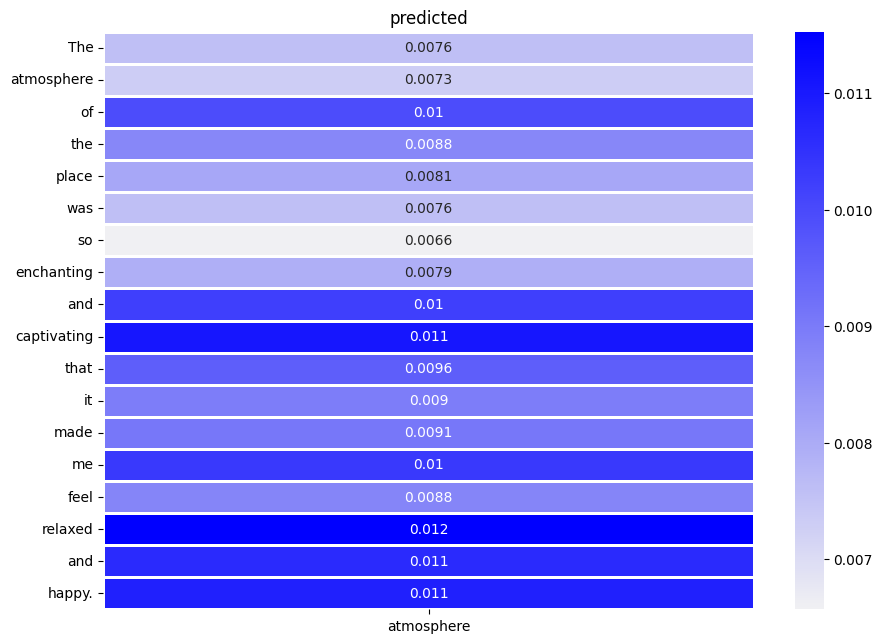






Review text :  that service was the worst thing I had ever experienced
******************************** aspect-term : service ********************************
******************************** Predicted Aspect ********************************
******************************** Positive ********************************


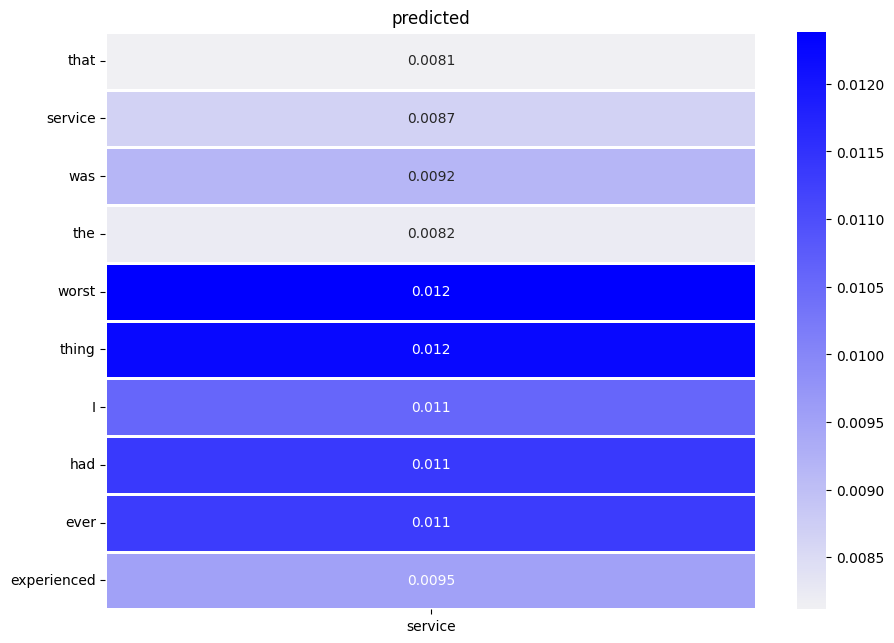

In [ ]:
# load the most accurate model, following val_acc curve
inp_str = 'The atmosphere of the place was so enchanting and captivating that it made me feel relaxed and happy.'

print_aspect(*predict_aspect(model, inp_str, 'atmosphere'), inp_str, 'atmosphere')

inp_str = 'that service was the worst thing I had ever experienced'
print_aspect(*predict_aspect(model, inp_str, 'service'), inp_str, 'service')

# **Attention Plot Analysis**

- For aspect term "Service" in above example.
- word `worst` is activated
- which cause negative sentiment prediction

-------------------------------------------------------------------
- For aspect term "ambience" in above example.
- words `captivating` and `happy` are activated
- which cause positive sentiment prediction.


## Other ways of interpreting language models: LIT Interpretability Tool

In [ ]:
from lit_nlp import notebook

In [ ]:
notebook.is_colab = True

In [ ]:
from lit_nlp.api.dataset import Dataset
from lit_nlp.api.model import Model
from lit_nlp.api import types as lit_types

In [ ]:
class LITModel(Model):
  """Wrapper for a Natural Language Inference model."""

  NLI_LABELS = ['negative', 'neutral', 'positive']

  def __init__(self, model):
    # Load the model into memory so we're ready for interactive use.
    self._model = model

  def predict_minibatch(self, inputs):

    outputs = []
    for input in inputs:
      review_text = input['review_text']
      aspect_text = input['aspect_text']

      probs, attn_weights = predict_aspect(self._model, review_text, aspect_text)
      outputs.append({
          'probs': probs,
      })

    return outputs


  def input_spec(self):
    """Describe the inputs to the model."""
    return {
        'review_text': lit_types.TextSegment(),
        'aspect_text': lit_types.TextSegment(),
    }

  def output_spec(self):
    """Describe the model outputs."""
    return {
      # The 'parent' keyword tells LIT where to look for gold labels when computing metrics.
      'probs': lit_types.MulticlassPreds(vocab = ['Positive', 'Negative'])
    }

In [ ]:
lit_model = LITModel(model)

In [ ]:
class LITDataset(Dataset):
  def __init__(self, dataset):
    self._examples = [{
      'review_text': row['text'],
      'aspect_text': row['term']
    } for _, row in dataset.iterrows()]

  def spec(self):
    return {
      'review_text': lit_types.TextSegment(),
      'aspect_text': lit_types.TextSegment(),
    }

In [ ]:
lit_dataset = LITDataset(train_data.sample(n = 50))

In [ ]:
widget = notebook.LitWidget({'model': lit_model}, {'ds': lit_dataset})

  0%|          | 0/50 [00:00<?, ?it/s]

In [ ]:
widget.render(height = 600)

<IPython.core.display.Javascript object>

## LIT Tool: Why Should we use it?

- The [Learning Interpretability Tool (LIT)](https://pair-code.github.io/lit/) is an open-source platform for visualization and understanding of NLP models.

- As you can see, we can use LIT tool to explore our trained data model. Here, we use it to have a look at the distribution of predicted sentiments by the model

## **Comaprison analysis & Conclusion**



### **Explainability**

Model  | Explainability
------------------------|-----------------------------
LSTM |  Not possible
LSTM + ATTN |  possible to visualize

## **Importance of Attention Mechanisms in training Popular  NLP Model**

* helps in learning good contexual representation of a text
* Adding Explainability
* helps in performance improvement
* Facilitates transfer learning


## **TRANSFORMERS**
- Language translation Model
- based on `MULTI-HEAD SELF-ATTENTION MECHANISMS`
- Get rid of recurrent architecture to understand text

## **BERT**

- Popular Language Model
- helps text to get good contexualised representation of text
- transfer learning
- based on `MULTI-HEAD SELF-ATTENTION MECHANISMS`


